# ADHD symptoms and academic outcomes

Complete, reproducible analysis of the supplied `archive.zip` / `ADHD.xlsx`.
The notebook contains the same implementation as `analysis.py`, with execution outputs and all final graphs.

**Research question:** Do students with ADHD benefit academically from institutional support?
First establish whether this dataset measures that exposure; if not, analyze defensible academic associations.

**Source:** [UCT/Zivahub dataset](https://doi.org/10.25375/uct.24906924), via the Kaggle mirror.
Instrument interpretation follows the [original study](https://doi.org/10.1177/10870547241310659).
These analyses use the workbook's PSY1004 course mark, not the paper's semester GPA.

Run all cells from this project folder with the packages in `requirements.txt`.
Implementation cells are collapsed for readability but contain the full code.

In [1]:
#!/usr/bin/env python3
"""Reproducible, source-audited analysis of the supplied ADHD.xlsx workbook.

Run: .venv/bin/python analysis.py
Optional: --input /path/to/archive.zip --output-dir /path/to/project --skip-png
No downloads, random variable searches, or automatic support proxies are used.
"""
from __future__ import annotations

import argparse
import contextlib
import hashlib
import io
import json
import os
import platform
import re
import sys
import zipfile
from importlib.metadata import version
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

SEED = 20260916
STUDY_URL = 'https://doi.org/10.1177/10870547241310659'
DATA_URL = 'https://doi.org/10.25375/uct.24906924'
SCREEN_URL = 'https://www.hcp.med.harvard.edu/ncs/ftpdir/adhd/ASRS_v1.1_screener%286Q%29_scoring_update.pdf'
NO_SUPPORT = ('This dataset does not contain a sufficiently clear variable for institutional '
              'academic support, so a support-vs-no-support comparison would not be valid.')
INATTENTION_ITEMS = [1, 2, 3, 4, 7, 8, 9, 10, 11]
HYPERACTIVITY_ITEMS = [5, 6, 12, 13, 14, 15, 16, 17, 18]
BLUE, ORANGE, INK = '#236B8E', '#BC5D25', '#213547'



ROOT = Path.cwd()
if not (ROOT / "data/ADHD.xlsx").exists():
    raise FileNotFoundError("Run this notebook from the adhd_academic_analysis folder.")
from IPython.display import display, Markdown, Image


In [2]:
def pstr(p):
    return f'{p:.2e}' if p < .001 else f'{p:.3f}'


def mdtable(df, digits=3):
    """Small Markdown tables without requiring tabulate."""
    def fmt(x):
        if isinstance(x, (float, np.floating)):
            return f'{x:.{digits}f}' if pd.notna(x) else 'NA'
        return str(x).replace('|', '/').replace('\n', ' ')
    lines = ['| ' + ' | '.join(map(str, df.columns)) + ' |',
             '| ' + ' | '.join(['---'] * len(df.columns)) + ' |']
    lines += ['| ' + ' | '.join(fmt(v) for v in row) + ' |' for row in df.itertuples(index=False, name=None)]
    return '\n'.join(lines)


def load_workbook(input_path, root):
    input_path, root = Path(input_path), Path(root)
    for sub in ['data', 'tables', 'outputs']:
        (root / sub).mkdir(parents=True, exist_ok=True)
    if input_path.suffix.lower() == '.zip':
        with zipfile.ZipFile(input_path) as z:
            members = z.namelist()
            workbooks = [n for n in members if n.lower().endswith('.xlsx') and not n.startswith('__MACOSX/')]
            if len(workbooks) != 1:
                raise ValueError(f'Expected one workbook, found {workbooks}')
            payload = z.read(workbooks[0])
    else:
        members, payload = [input_path.name], input_path.read_bytes()
    (root / 'data' / 'ADHD.xlsx').write_bytes(payload)
    book = pd.ExcelFile(io.BytesIO(payload))
    # Preserve literal 'no', 'none', and 'not applicable': these are responses, not blanks.
    raw = pd.read_excel(book, sheet_name='Sheet1', keep_default_na=False).replace('', np.nan)
    for col in raw.columns:
        numeric = pd.to_numeric(raw[col], errors='coerce')
        if raw[col].notna().sum() and numeric.notna().sum() == raw[col].notna().sum():
            raw[col] = numeric
    outliers = pd.read_excel(book, sheet_name='Outliers', header=None, keep_default_na=False).replace('', np.nan)
    import openpyxl
    wb = openpyxl.load_workbook(io.BytesIO(payload), data_only=False)
    metadata = {
        'archive_members': members, 'workbook_sha256': hashlib.sha256(payload).hexdigest(),
        'sheets': book.sheet_names, 'main_shape': list(raw.shape),
        'outliers_shape_headerless': list(outliers.shape),
        'cell_comments': sum(c.comment is not None for sh in wb for row in sh for c in row),
        'named_ranges': list(wb.defined_names),
        'sheet_states': {sh.title: sh.sheet_state for sh in wb},
        'excel_error_counts': {sh.title: sum(c.data_type == 'e' or (c.data_type == 'f' and '#REF!' in c.value)
                                           for row in sh for c in row) for sh in wb},
        'duplicate_rows_main': int(raw.duplicated().sum()),
        'outliers_missing_course_marks': int(outliers.iloc[:, raw.columns.get_loc('psy1004_grade')].isna().sum()),
    }
    return raw, metadata


def inspect_dataset(raw, metadata, root):
    root = Path(root)
    schema = pd.DataFrame({'column': raw.columns, 'dtype': raw.dtypes.astype(str).values,
                           'missing': raw.isna().sum().values,
                           'missing_percent': raw.isna().mean().values * 100,
                           'unique_nonmissing': raw.nunique().values})
    schema.to_csv(root / 'tables/schema_missingness.csv', index=False)
    desc = raw.describe(include='all').T
    desc.to_csv(root / 'tables/descriptive_statistics_all_columns.csv')
    # Full unique-value counts for categorical columns; local audit only, no narratives in graphs.
    value_counts = {c: {str(k): int(v) for k, v in raw[c].value_counts(dropna=False).items()}
                    for c in raw.columns if not pd.api.types.is_numeric_dtype(raw[c])}
    (root / 'tables/categorical_value_counts.json').write_text(json.dumps(value_counts, indent=2))
    print('WORKBOOK INVENTORY\n', json.dumps(metadata, indent=2))
    print('\nSHAPE:', raw.shape)
    print('\nALL COLUMN NAMES\n', '\n'.join(raw.columns))
    print('\nDATA TYPES AND MISSING COUNTS\n', schema.to_string(index=False))
    print('\nBASIC DESCRIPTIVE STATISTICS\n', desc.to_string())
    print('\nDIAGNOSIS / TREATMENT VALUE LABELS')
    for c in raw.columns:
        if any(term in c for term in ['diagnosed_with', 'psychiatric_medication', 'therapy_or_counselling']):
            print(c, raw[c].value_counts(dropna=False).to_dict())
    terms = {
        'ADHD diagnosis': r'diagnos', 'ADHD symptoms': r'asrs|adhd|inatten|hyperactiv|impuls',
        'Academic performance / marks': r'gpa|grade|mark|performance|nbt',
        'Academic adjustment': r'aas|adjust',
        'Institutional academic support': r'accommodat|disabilit|mentor|tutor|advis|coach|study_support|academic_support',
        'Help-seeking / mental-health support / treatment': r'help|seek|support|counsell|therap|medicat|treat',
    }
    rows = []
    for category, pattern in terms.items():
        matches = [c for c in raw.columns if re.search(pattern, c, re.I)]
        rows.append({'category': category, 'matched_columns': '; '.join(matches) or 'NONE'})
    search = pd.DataFrame(rows)
    search.to_csv(root / 'tables/variable_search.csv', index=False)
    print('\nVARIABLE SEARCH\n', search.to_string(index=False))
    print('\nSUPPORT DECISION\n', NO_SUPPORT)
    return schema

## 1. Load and inspect all data

Print shape, every column, data types, missing values, descriptive statistics and treatment/diagnosis labels.
Inspect both sheets and spreadsheet metadata. Literal `no`, `none` and `not applicable` are preserved.
Complete categorical unique-value counts are also saved locally; participant narratives never appear in graphs.

In [3]:
raw, metadata = load_workbook(ROOT / "data/ADHD.xlsx", ROOT)
schema = inspect_dataset(raw, metadata, ROOT)

WORKBOOK INVENTORY
 {
  "archive_members": [
    "ADHD.xlsx"
  ],
  "workbook_sha256": "84373cad739c5e315fd7a94c0fc98627936d1a9291265fca0a71545f4d561c3a",
  "sheets": [
    "Sheet1",
    "Outliers"
  ],
  "main_shape": [
    506,
    110
  ],
  "outliers_shape_headerless": [
    10,
    111
  ],
  "cell_comments": 0,
  "named_ranges": [],
  "sheet_states": {
    "Sheet1": "visible",
    "Outliers": "visible"
  },
  "excel_error_counts": {
    "Sheet1": 0,
    "Outliers": 10
  },
  "duplicate_rows_main": 0,
  "outliers_missing_course_marks": 10
}

SHAPE: (506, 110)

ALL COLUMN NAMES
 age
sex
specify
home_language
have_you_ever_experienced_any_mental_health_difficulties_or_symptoms_before_starting_university_e_g_in_primary_or_high_school
if_yes_please_list_these_difficulties_and_or_symptoms
if_you_have_ever_experienced_difficulties_and_or_symptoms_of_a_mental_illness_how_old_were_you_when_this_started
have_you_ever_been_diagnosed_with_a_mental_illness
if_you_have_been_diagnosed_formally_

## 2. Support feasibility and variable validation

**This dataset does not contain a sufficiently clear variable for institutional academic support, so a support-vs-no-support comparison would not be valid.**

Medication and counselling are general psychiatric history questions, with no academic purpose or institutional provider specified. No support exposure is constructed.

Validate questionnaire totals against their constituent items, require complete items, and distinguish symptoms from diagnosis. The six-item screening sum uses the [Harvard/NCS research rule](https://www.hcp.med.harvard.edu/ncs/ftpdir/adhd/ASRS_v1.1_screener%286Q%29_scoring_update.pdf): ≥14 is screen positive, not a diagnosis. No arbitrary median split is used.

Main adjustment analyses use only complete nine-item AAS responses. Anxiety is reconstructed because some provided totals disagree with the items. The `asrs1_total.y` field is not used as ADHD severity.

In [4]:
def prepare_data(raw, metadata, root):
    root = Path(root)
    d = pd.DataFrame(index=raw.index)
    d['source_excel_row'] = raw.index + 2
    checks = []
    for prefix, nitems, maximum, stored in [
        ('asrs1', 18, 4, 'asrs1_total.x'), ('aas1', 9, 5, 'aas1_total'),
        ('bdi1', 21, 3, 'bdi1_total'), ('bai1', 21, 3, 'bai1_total')]:
        cols = [f'{prefix}_item_{i}' for i in range(1, nitems + 1)]
        items = raw[cols].apply(pd.to_numeric, errors='raise')
        minimum = 1 if prefix == 'aas1' else 0
        valid = items.isna() | ((items >= minimum) & (items <= maximum) & (items % 1 == 0))
        if not valid.all().all():
            raise ValueError(f'Invalid item values in {prefix}; review before analysis.')
        total = items.sum(axis=1, min_count=nitems)
        existing = pd.to_numeric(raw[stored], errors='coerce')
        checks.append({'scale': prefix, 'item_complete_n': int(total.notna().sum()),
                       'item_incomplete_n': int(total.isna().sum()),
                       'stored_total_mismatches_among_complete': int(((total != existing) & total.notna()).sum())})
        name = {'asrs1': 'adhd_total', 'aas1': 'adjustment', 'bdi1': 'depression', 'bai1': 'anxiety'}[prefix]
        d[name] = total
    for name, indices in [('inattention', INATTENTION_ITEMS), ('hyperactivity', HYPERACTIVITY_ITEMS)]:
        d[name] = raw[[f'asrs1_item_{i}' for i in indices]].sum(axis=1, min_count=len(indices))
    assert np.allclose(d.inattention + d.hyperactivity, d.adhd_total)
    for name, col in [('course_mark', 'psy1004_grade'), ('age', 'age'), ('matric_mark', 'matric_mark'),
                      ('nbt_alql', 'nbt_alql_ave'), ('adjustment_change', 'aas_change')]:
        d[name] = pd.to_numeric(raw[col], errors='raise')
    assert d.course_mark.dropna().between(0, 100).all()
    # Research screening definition, not a clinical diagnosis. No total-score median split.
    screen = raw[[f'asrs1_item_{i}' for i in range(1, 7)]].sum(axis=1, min_count=6)
    d['asrs6_sum'] = screen
    d['screen_positive'] = (screen >= 14).astype('Int64').mask(screen.isna())
    d['screen_label'] = d.screen_positive.map({0: 'Screen negative', 1: 'Screen positive'})
    d['adjustment_stored_sensitivity'] = pd.to_numeric(raw.aas1_total)
    d['anxiety_stored_sensitivity'] = pd.to_numeric(raw.bai1_total)
    checks = pd.DataFrame(checks)
    checks.to_csv(root / 'tables/scale_validation.csv', index=False)
    d.to_csv(root / 'data/analysis_variables.csv', index=False)
    metadata.update({
        'asrs_x_item_sum_matches': int(d.adhd_total.eq(raw['asrs1_total.x']).sum()),
        'asrs_y_item_sum_matches': int(d.adhd_total.eq(raw['asrs1_total.y']).sum()),
        'asrs_y_anxiety_item_sum_matches': int(d.anxiety.eq(raw['asrs1_total.y']).sum()),
        'analysis_n': len(d), 'adjustment_complete_n': int(d.adjustment.notna().sum()),
        'adjustment_change_n': int(d.adjustment_change.notna().sum()),
    })
    (root / 'tables/workbook_inventory.json').write_text(json.dumps(metadata, indent=2))
    print('\nSCALE VALIDATION\n', checks.to_string(index=False))
    print('\nANALYSIS VARIABLES\n', d.describe().T.to_string())
    return d, checks

In [5]:
d, checks = prepare_data(raw, metadata, ROOT)
display(checks)


SCALE VALIDATION
 scale  item_complete_n  item_incomplete_n  stored_total_mismatches_among_complete
asrs1              506                  0                                       0
 aas1              488                 18                                       0
 bdi1              506                  0                                       0
 bai1              506                  0                                      61

ANALYSIS VARIABLES
                                count       mean         std       min       25%       50%       75%       max
source_excel_row               506.0      254.5  146.213884       2.0    128.25     254.5    380.75     507.0
adhd_total                     506.0   35.66996   11.509435       0.0     27.25      35.0     43.75      70.0
adjustment                     488.0   31.14959    4.828066       9.0      28.0      32.0      35.0      45.0
depression                     506.0  16.312253   10.308572       0.0       9.0      15.0      23.0      58.0


,scale,item_complete_n,item_incomplete_n,stored_total_mismatches_among_complete
0,asrs1,506,0,0
1,aas1,488,18,0
2,bdi1,506,0,0
3,bai1,506,0,61


## 3. Focused statistical analyses

Primary comparisons: ADHD total, inattention and hyperactivity against course marks and baseline adjustment; screening groups; both symptom dimensions in a joint mark model and their standardized contrast.

Report Pearson and Spearman associations, mean/median/SD, 95% CIs, Welch and Mann–Whitney results, Cohen's d, Hedges' g, regression coefficients, p-values and R². HC3 intervals allow unequal residual variance. Ten primary tests use Holm adjustment. Four separate, targeted secondary correlations assess the imported adjustment-change index and overlap with depression/anxiety.

Sensitivity models add age, matric mark and NBT literacy average. Retain null results. Inference is observational, with no causal effect or Kazakhstan-specific inference. Covariate and sensitivity p-values are nominal; intervals are pointwise.

In [6]:
def association(d, x, y, family):
    pair = d[[x, y]].dropna()
    r, p = stats.pearsonr(pair[x], pair[y])
    rho, sp = stats.spearmanr(pair[x], pair[y])
    n = len(pair)
    lo, hi = np.tanh(np.arctanh(r) + np.array([-1, 1]) * stats.norm.ppf(.975) / np.sqrt(n - 3))
    model = sm.OLS(pair[y], sm.add_constant(pair[[x]])).fit(cov_type='HC3', use_t=True)
    ci = model.conf_int().loc[x]
    return {'test_id': f'{x}__{y}', 'family': family, 'predictor': x, 'outcome': y, 'n': n,
            'pearson_r': r, 'r_ci_low': lo, 'r_ci_high': hi, 'p': p,
            'spearman_rho': rho, 'spearman_p': sp, 'slope': model.params[x],
            'slope_ci_low': ci.iloc[0], 'slope_ci_high': ci.iloc[1],
            'slope_p_HC3': model.pvalues[x], 'R_squared': model.rsquared}, model


def compare_groups(d):
    positive = d.loc[d.screen_positive == 1, 'course_mark'].dropna().to_numpy()
    negative = d.loc[d.screen_positive == 0, 'course_mark'].dropna().to_numpy()
    summaries = []
    for label, a in [('Screen negative', negative), ('Screen positive', positive)]:
        ci = stats.t.interval(.95, len(a)-1, loc=a.mean(), scale=stats.sem(a))
        summaries.append({'group': label, 'n': len(a), 'mean': a.mean(), 'median': np.median(a),
                          'sd': a.std(ddof=1), 'mean_ci_low': ci[0], 'mean_ci_high': ci[1],
                          'skewness': stats.skew(a, bias=False)})
    result = stats.ttest_ind(positive, negative, equal_var=False)
    n1, n0 = len(positive), len(negative)
    v1, v0 = positive.var(ddof=1), negative.var(ddof=1)
    diff = positive.mean()-negative.mean()
    se = np.sqrt(v1/n1+v0/n0)
    ci = diff + np.array([-1, 1])*stats.t.ppf(.975, result.df)*se
    pooled_sd = np.sqrt(((n1-1)*v1+(n0-1)*v0)/(n1+n0-2))
    cohen_d = diff/pooled_sd
    hedges_g = cohen_d*(1-3/(4*(n1+n0)-9))
    rng = np.random.default_rng(SEED)
    boot = []
    for _ in range(5000):
        a, b = rng.choice(positive, n1), rng.choice(negative, n0)
        sd = np.sqrt(((n1-1)*a.var(ddof=1)+(n0-1)*b.var(ddof=1))/(n1+n0-2))
        boot.append((a.mean()-b.mean())/sd*(1-3/(4*(n1+n0)-9)))
    gci = np.quantile(boot, [.025, .975])
    u = stats.mannwhitneyu(positive, negative, alternative='two-sided', method='asymptotic')
    comparison = {'test_id': 'screen_welch', 'family': 'primary', 'positive_n': n1, 'negative_n': n0,
                  'mean_difference_positive_minus_negative': diff, 'difference_ci_low': ci[0],
                  'difference_ci_high': ci[1], 'welch_t': result.statistic, 'welch_df': result.df,
                  'p': result.pvalue, 'cohens_d': cohen_d, 'hedges_g': hedges_g,
                  'g_bootstrap_ci_low': gci[0], 'g_bootstrap_ci_high': gci[1],
                  'mann_whitney_u': u.statistic, 'mann_whitney_p': u.pvalue,
                  'rank_biserial_positive_minus_negative': 2*u.statistic/(n1*n0)-1,
                  'levene_median_p': stats.levene(positive, negative, center='median').pvalue}
    return pd.DataFrame(summaries), comparison


def fit_model(d, outcome, predictors, name, standardize=False):
    data = d[[outcome] + predictors].dropna()
    X = data[predictors].copy()
    if standardize:
        for col in ['inattention', 'hyperactivity']:
            X[col] = (X[col]-X[col].mean())/X[col].std(ddof=1)
    X = sm.add_constant(X)
    model = sm.OLS(data[outcome], X).fit(cov_type='HC3', use_t=True)
    rows = []
    for col in X.columns:
        ci = model.conf_int().loc[col]
        rows.append({'model': name, 'outcome': outcome, 'term': col, 'n': len(data),
                     'coefficient': model.params[col], 'ci_low': ci.iloc[0], 'ci_high': ci.iloc[1],
                     'p': model.pvalues[col], 'R_squared': model.rsquared,
                     'adjusted_R_squared': model.rsquared_adj,
                     'unit': 'per 1 SD (symptoms only)' if standardize else 'per 1 raw point'})
    # Diagnostics are descriptive; HC3 is used for all models regardless of diagnostics.
    influence = sm.OLS(data[outcome], X).fit().get_influence()
    diag = {'model': name, 'n': len(data), 'residual_skew': stats.skew(model.resid, bias=False),
            'breusch_pagan_p': het_breuschpagan(model.resid, X)[1],
            'cooks_d_max': float(influence.cooks_distance[0].max()),
            'cooks_d_above_4_over_n': int((influence.cooks_distance[0] > 4/len(data)).sum()),
            'R_squared': model.rsquared}
    for i, col in enumerate(X.columns):
        if col != 'const':
            diag[f'VIF_{col}'] = variance_inflation_factor(X.to_numpy(), i)
    return model, rows, diag


def analyze(d, root):
    root = Path(root)
    associations, simple_models = [], {}
    # Fixed, research-led family: three symptom measures x two academic outcomes.
    for y in ['course_mark', 'adjustment']:
        for x in ['adhd_total', 'inattention', 'hyperactivity']:
            row, model = association(d, x, y, 'primary')
            associations.append(row)
            simple_models[row['test_id']] = model
    # Four targeted secondary associations, not an all-column correlation sweep.
    for x, y in [('adhd_total', 'adjustment_change'), ('inattention', 'adjustment_change'),
                 ('inattention', 'depression'), ('inattention', 'anxiety')]:
        row, model = association(d, x, y, 'secondary')
        associations.append(row)
        simple_models[row['test_id']] = model
    associations = pd.DataFrame(associations)
    groups, group_test = compare_groups(d)
    models, coefficients, diagnostics = {}, [], []
    controls = ['age', 'matric_mark', 'nbt_alql']
    specs = [
        ('course_mark', ['inattention', 'hyperactivity'], 'marks_joint_raw', False),
        ('course_mark', ['inattention', 'hyperactivity'], 'marks_joint_sd', True),
        ('course_mark', ['inattention', 'hyperactivity'] + controls, 'marks_adjusted_raw', False),
        ('course_mark', ['inattention', 'hyperactivity'] + controls, 'marks_adjusted_sd', True),
        ('adjustment', ['inattention', 'hyperactivity'], 'adjustment_joint_raw', False),
        ('adjustment', ['inattention', 'hyperactivity'] + controls, 'adjustment_adjusted_raw', False),
        ('adjustment_change', ['inattention', 'hyperactivity'] + controls, 'change_adjusted_raw', False),
    ]
    for outcome, preds, name, standardized in specs:
        m, rows, diag = fit_model(d, outcome, preds, name, standardized)
        models[name] = m
        coefficients.extend(rows)
        diagnostics.append(diag)
    coefficients = pd.DataFrame(coefficients)
    # Direct coefficient contrast; a difference in significance is not itself a significant difference.
    contrast = models['marks_joint_sd'].t_test([0, 1, -1])
    cc = contrast.conf_int()[0]
    contrast_row = {'test_id': 'symptom_coefficient_contrast', 'family': 'primary',
                    'difference_per_SD': float(np.asarray(contrast.effect).item()),
                    'ci_low': float(cc[0]), 'ci_high': float(cc[1]),
                    'p': float(np.asarray(contrast.pvalue).item())}
    primary = associations.loc[associations.family == 'primary', ['test_id', 'family', 'p']].to_dict('records')
    primary.append({k: group_test[k] for k in ['test_id', 'family', 'p']})
    for term in ['inattention', 'hyperactivity']:
        primary.append({'test_id': f'joint_coefficient_{term}', 'family': 'primary',
                        'p': models['marks_joint_raw'].pvalues[term]})
    primary.append({k: contrast_row[k] for k in ['test_id', 'family', 'p']})
    primary = pd.DataFrame(primary)
    primary['p_holm'] = multipletests(primary.p, method='holm')[1]
    secondary = associations.loc[associations.family == 'secondary', ['test_id', 'family', 'p']].copy()
    secondary['p_holm'] = multipletests(secondary.p, method='holm')[1]
    tests = pd.concat([primary, secondary], ignore_index=True)
    associations = associations.merge(tests[['test_id', 'p_holm']], on='test_id', validate='one_to_one')
    group_test['p_holm'] = float(tests.set_index('test_id').loc['screen_welch', 'p_holm'])
    contrast_row['p_holm'] = float(tests.set_index('test_id').loc['symptom_coefficient_contrast', 'p_holm'])
    # Sensitivity: stored partial AAS totals, stored anxiety totals, and influence on main associations.
    sensitivity = []
    for x, y in [('inattention', 'adjustment_stored_sensitivity'),
                 ('adhd_total', 'adjustment_stored_sensitivity'),
                 ('inattention', 'anxiety_stored_sensitivity')]:
        r, _ = association(d, x, y, 'sensitivity')
        sensitivity.append(r)
    for x, y in [('inattention', 'course_mark'), ('inattention', 'adjustment')]:
        pair = d[[x, y]].dropna()
        m = sm.OLS(pair[y], sm.add_constant(pair[[x]])).fit()
        keep = m.get_influence().cooks_distance[0] <= 4/len(pair)
        r, _ = association(pair.loc[keep], x, y, 'sensitivity_excluding_cooks_d_gt_4_over_n')
        sensitivity.append(r)
    # Describe selection into the subset with imported adjustment change; do not call it random attrition.
    retention = d.assign(change_available=d.adjustment_change.notna()).groupby('change_available').agg(
        n=('course_mark', 'size'), mean_course_mark=('course_mark', 'mean'),
        mean_inattention=('inattention', 'mean'), mean_ADHD=('adhd_total', 'mean'))
    for filename, frame in [('associations', associations), ('primary_secondary_tests', tests),
                            ('screen_group_statistics', groups), ('screen_comparison', pd.DataFrame([group_test])),
                            ('regression_coefficients', coefficients), ('model_diagnostics', pd.DataFrame(diagnostics)),
                            ('coefficient_contrast', pd.DataFrame([contrast_row])),
                            ('sensitivity_analyses', pd.DataFrame(sensitivity))]:
        frame.to_csv(root / f'tables/{filename}.csv', index=False)
    retention.to_csv(root / 'tables/change_subset_selection.csv')
    print('\nPLANNED ASSOCIATIONS\n', associations.to_string(index=False))
    print('\nSCREENING GROUP DESCRIPTIVES\n', groups.to_string(index=False))
    print('\nSCREENING GROUP TEST\n', json.dumps(group_test, indent=2))
    print('\nREGRESSION COEFFICIENTS (HC3 95% CIs)\n', coefficients.to_string(index=False))
    print('\nSYMPTOM COEFFICIENT CONTRAST\n', contrast_row)
    print('\nSENSITIVITY ANALYSES\n', pd.DataFrame(sensitivity).to_string(index=False))
    print('\nCHANGE-SUBSET SELECTION\n', retention.to_string())
    return dict(associations=associations, models=models, simple_models=simple_models, groups=groups,
                group_test=group_test, coefficients=coefficients, tests=tests, contrast=contrast_row,
                diagnostics=pd.DataFrame(diagnostics), retention=retention)

In [7]:
result = analyze(d, ROOT)


PLANNED ASSOCIATIONS
                        test_id    family     predictor           outcome   n  pearson_r  r_ci_low  r_ci_high            p  spearman_rho   spearman_p     slope  slope_ci_low  slope_ci_high  slope_p_HC3  R_squared       p_holm
       adhd_total__course_mark   primary    adhd_total       course_mark 506  -0.040740 -0.127456   0.046594 3.604301e-01     -0.032298 4.685024e-01 -0.039647     -0.123610       0.044317 3.540067e-01   0.001660 1.000000e+00
      inattention__course_mark   primary   inattention       course_mark 506  -0.107146 -0.192517  -0.020166 1.590114e-02     -0.103353 2.005323e-02 -0.179395     -0.330579      -0.028212 2.013057e-02   0.011480 7.950569e-02
    hyperactivity__course_mark   primary hyperactivity       course_mark 506   0.039431 -0.047902   0.126166 3.760884e-01      0.046155 3.001026e-01  0.070257     -0.080396       0.220911 3.599855e-01   0.001555 1.000000e+00
        adhd_total__adjustment   primary    adhd_total        adjustment 488 

In [8]:
display(result["tests"])
display(result["diagnostics"])

,test_id,family,p,p_holm
0,adhd_total__course_mark,primary,3.604301e-01,1.000000e+00
1,inattention__course_mark,primary,1.590114e-02,7.950569e-02
2,hyperactivity__course_mark,primary,3.760884e-01,1.000000e+00
3,adhd_total__adjustment,primary,2.150854e-03,1.505598e-02
4,inattention__adjustment,primary,5.119545e-06,5.119545e-05
5,hyperactivity__adjustment,primary,4.403250e-01,1.000000e+00
6,screen_welch,primary,3.154294e-02,1.261718e-01
7,joint_coefficient_inattention,primary,7.599123e-04,6.079298e-03
8,joint_coefficient_hyperactivity,primary,4.425979e-03,2.655588e-02
9,symptom_coefficient_contrast,primary,4.842835e-04,4.358552e-03


,model,n,residual_skew,breusch_pagan_p,cooks_d_max,cooks_d_above_4_over_n,R_squared,VIF_inattention,VIF_hyperactivity,VIF_age,VIF_matric_mark,VIF_nbt_alql
0,marks_joint_raw,506,-0.140744,0.240486,0.046726,24,0.026622,1.489128,1.489128,NaN,NaN,NaN
1,marks_joint_sd,506,-0.140744,0.240486,0.046726,24,0.026622,1.489128,1.489128,NaN,NaN,NaN
2,marks_adjusted_raw,506,-0.268519,0.844074,0.033057,21,0.293588,1.541289,1.545315,1.009232,1.278382,1.278117
3,marks_adjusted_sd,506,-0.268519,0.844074,0.033057,21,0.293588,1.541289,1.545315,1.009232,1.278382,1.278117
4,adjustment_joint_raw,488,-0.523477,0.454532,0.033639,29,0.051678,1.476341,1.476341,NaN,NaN,NaN
5,adjustment_adjusted_raw,488,-0.499257,0.602471,0.024873,24,0.067292,1.529443,1.534324,1.011264,1.279582,1.279163
6,change_adjusted_raw,176,-0.244943,0.224381,0.092894,7,0.129094,1.660947,1.677504,1.032000,1.350402,1.365943


## 4. Presentation graphs

Full 0–100 scales are used for course marks; AAS uses its mathematical 9–45 range. Scatter bands show confidence intervals for the fitted mean, not prediction intervals. Figures are saved as standalone Plotly HTML and as PNG when Kaleido/Chrome is available. The final section ranks exactly three recommended graphs.

In [9]:
def style(fig, title, subtitle, xlabel, ylabel, footnote):
    fig.update_layout(template='simple_white', width=1200, height=760,
                      font=dict(family='Arial, sans-serif', size=21, color=INK),
                      title=dict(text=f'<b>{title}</b><br><span style="font-size:18px">{subtitle}</span>',
                                 x=.055, xanchor='left', y=.94, yanchor='top', font=dict(size=27)),
                      margin=dict(l=110, r=55, t=140, b=170),
                      xaxis_title=xlabel, yaxis_title=ylabel,
                      showlegend=False, paper_bgcolor='white', plot_bgcolor='white',
                      hoverlabel=dict(font_size=16))
    fig.update_xaxes(showgrid=False, zeroline=False, ticks='outside', title_standoff=18)
    fig.update_yaxes(showgrid=True, gridcolor='#E7EDF0', zeroline=False, ticks='outside', title_standoff=18)
    fig.add_annotation(x=0, y=-.25, xref='paper', yref='paper', text=footnote,
                       showarrow=False, align='left', xanchor='left', yanchor='top',
                       font=dict(size=15, color='#526270'))
    return fig


def scatter_figure(d, result, x, y, title, xlabel, ylabel, xrange, yrange, footer_extra=''):
    r = result['associations'].set_index('test_id').loc[f'{x}__{y}']
    pair = d[[x, y]].dropna()
    model = result['simple_models'][f'{x}__{y}']
    grid = np.linspace(pair[x].min(), pair[x].max(), 150)
    prediction = model.get_prediction(sm.add_constant(pd.DataFrame({x: grid}))).summary_frame()
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=grid, y=prediction.mean_ci_upper, mode='lines', line=dict(width=0),
                             hoverinfo='skip', showlegend=False))
    fig.add_trace(go.Scatter(x=grid, y=prediction.mean_ci_lower, mode='lines', line=dict(width=0),
                             fill='tonexty', fillcolor='rgba(35,107,142,0.15)', hoverinfo='skip'))
    fig.add_trace(go.Scatter(x=pair[x], y=pair[y], mode='markers',
                             marker=dict(color=BLUE, size=8, opacity=.36, line=dict(width=0)),
                             hovertemplate='%{x:.1f}<br>%{y:.2f}<extra></extra>', name='Students'))
    fig.add_trace(go.Scatter(x=grid, y=prediction['mean'], mode='lines', line=dict(color=BLUE, width=3),
                             hoverinfo='skip', name='Linear fit'))
    subtitle = (f'n = {int(r.n)}  |  r = {r.pearson_r:.2f}  |  p = {pstr(r.p)}'
                f'  |  Holm-adjusted p = {pstr(r.p_holm)}')
    footer = 'Dots: students. Line: linear fit; band: 95% CI for the mean (HC3).'
    footer += '<br>' + (footer_extra or 'South African first-year sample. Association does not establish causation or support effectiveness.')
    style(fig, title, subtitle, xlabel, ylabel, footer)
    fig.update_xaxes(range=xrange)
    fig.update_yaxes(range=yrange)
    return fig


def create_figures(d, result):
    figures = {}
    specs = [
        ('adhd_severity_vs_academic_performance', 'adhd_total', 'course_mark',
         'ADHD symptom severity and course marks', 'ADHD symptom score (ASRS, 0–72)', 'PSY1004 course mark (%)', [0,72], [0,100],
         'Course mark, not GPA. No clear overall ADHD–mark association in this sample.'),
        ('inattention_vs_academic_performance', 'inattention', 'course_mark',
         'Inattention and course marks', 'Inattention score (0–36; higher = more symptoms)', 'PSY1004 course mark (%)', [0,36], [0,100],
         'Small unadjusted association; weaker after accounting for age and prior attainment. Course mark, not GPA.'),
        ('adhd_vs_academic_adjustment', 'adhd_total', 'adjustment',
         'ADHD symptoms and academic adjustment', 'ADHD symptom score (ASRS, 0–72)', 'Academic adjustment score (9–45)', [0,72], [9,45],
         'Higher adjustment scores = better adjustment. Same-time self-reports; 18 incomplete AAS responses excluded.'),
        ('inattention_vs_academic_adjustment', 'inattention', 'adjustment',
         'More inattention, poorer academic adjustment', 'Inattention score (0–36; higher = more symptoms)', 'Academic adjustment score (9–45)', [0,36], [9,45],
         'Higher adjustment scores = better adjustment. Same-time self-reports; support use was not measured.'),
        ('inattention_vs_adjustment_change', 'inattention', 'adjustment_change',
         'Inattention and the adjustment-change index', 'Inattention score (0–36)', 'Imported change index (model units)', [0,36], [-7,6],
         'Exploratory: 176/506 students; source-derived index cannot be reconstructed from the supplied workbook.'),
    ]
    for filename, x, y, title, xl, yl, xr, yr, footer in specs:
        figures[filename] = scatter_figure(d, result, x, y, title, xl, yl, xr, yr, footer)
    g = result['group_test']
    fig = go.Figure()
    rng = np.random.default_rng(SEED)
    labels = []
    for i, (label, color) in enumerate([('Screen negative', BLUE), ('Screen positive', ORANGE)]):
        a = d.loc[d.screen_label == label, 'course_mark'].dropna()
        labels.append(f'{label}<br>n = {len(a)}')
        fig.add_trace(go.Box(x=np.full(len(a), i), y=a, name=label, width=.42, boxpoints=False,
                             line=dict(color=color, width=2), fillcolor='rgba(255,255,255,0)',
                             quartilemethod='linear', whiskerwidth=.7))
        fig.add_trace(go.Scatter(x=i+rng.uniform(-.15,.15,len(a)), y=a, mode='markers',
                                 marker=dict(color=color, size=7, opacity=.35), name=label,
                                 hovertemplate='Course mark: %{y:.0f}%<extra></extra>'))
    style(fig, 'Course marks by ADHD screening status',
          f'Mean difference = {g["mean_difference_positive_minus_negative"]:.2f} percentage points  |  '
          f'Welch p = {pstr(g["p"])}  |  Holm p = {pstr(g["p_holm"])}',
          '', 'PSY1004 course mark (%)',
          'ASRS six-item sum ≥14 = screen positive. Screening is not diagnosis; screen negative does not rule out ADHD.'
          '<br>Boxes: median and middle 50%; whiskers: up to 1.5×IQR. Dots: all students. Course mark, not GPA.')
    fig.update_xaxes(tickvals=[0,1], ticktext=labels, range=[-.55,1.55])
    fig.update_yaxes(range=[0,100])
    figures['adhd_screening_vs_academic_performance'] = fig
    # Compare coefficients in the same units and show attenuation after prior attainment is included.
    fig = go.Figure()
    for model, label, color, offset in [
        ('marks_joint_sd', 'Both symptom dimensions', BLUE, .10),
        ('marks_adjusted_sd', '+ age and prior attainment', ORANGE, -.10)]:
        c = result['coefficients'].query('model == @model').set_index('term').loc[['inattention','hyperactivity']]
        fig.add_trace(go.Scatter(x=c.coefficient, y=np.array([1,0])+offset, mode='markers', name=label,
                                 marker=dict(size=13,color=color),
                                 error_x=dict(type='data', symmetric=False, array=c.ci_high-c.coefficient,
                                              arrayminus=c.coefficient-c.ci_low, thickness=2, width=7),
                                 hovertemplate='%{x:.2f} percentage points per SD<extra>%{fullData.name}</extra>'))
    style(fig, 'Inattention and marks: accounting for prior attainment',
          f'n = {len(d)}  |  Joint-model R² = {result["models"]["marks_joint_sd"].rsquared:.3f}'
          f'  |  With covariates R² = {result["models"]["marks_adjusted_sd"].rsquared:.3f}',
          'Course-mark difference per 1 SD of symptoms (percentage points)', '',
          'Points: regression coefficients; bars: 95% HC3 CIs. Both dimensions enter each model together.'
          '<br>Covariates: age, matric mark and NBT literacy. Conditional associations; no causal interpretation.')
    fig.update_yaxes(tickvals=[1,0], ticktext=['Inattention','Hyperactivity /<br>impulsivity'], range=[-.5,1.5],showgrid=False)
    fig.update_xaxes(range=[-4,4],showgrid=True,gridcolor='#E7EDF0')
    fig.add_vline(x=0,line_width=1.5,line_dash='dash',line_color='#777777')
    fig.update_layout(margin=dict(l=240,r=55,t=165,b=170),showlegend=True,
                      legend=dict(orientation='h',x=0,y=1.17,font_size=17))
    figures['symptom_dimensions_vs_academic_performance'] = fig
    # One targeted extra finding: symptom overlap, not inferred clinical comorbidity.
    fig = go.Figure()
    rows = result['associations'].set_index('test_id').loc[['inattention__depression','inattention__anxiety']]
    fig.add_trace(go.Scatter(x=rows.pearson_r,y=[1,0],mode='markers',marker=dict(color=BLUE,size=15),
                             error_x=dict(type='data',symmetric=False,array=rows.r_ci_high-rows.pearson_r,
                                          arrayminus=rows.pearson_r-rows.r_ci_low,thickness=2,width=8)))
    style(fig,'Inattention and other mental-health symptoms',
          'n = 506  |  Pearson correlations with 95% confidence intervals',
          'Correlation with inattention (r)', '',
          'Depression: BDI-II item sum. Anxiety: BAI item sum; corrected for inconsistent supplied totals.'
          '<br>Concurrent self-reports measure symptom overlap, not confirmed diagnoses or causes.')
    fig.update_xaxes(range=[-1,1],showgrid=True,gridcolor='#E7EDF0')
    fig.update_yaxes(tickvals=[1,0],ticktext=['Depressive symptoms','Anxiety symptoms'],range=[-.5,1.5],showgrid=False)
    fig.update_layout(margin=dict(l=250,r=55,t=140,b=170))
    fig.add_vline(x=0,line_width=1,line_dash='dash',line_color='#777777')
    figures['inattention_and_mental_health_symptoms'] = fig
    return figures


def export_figures(figures, root, png=True):
    root = Path(root)
    browser = root / '.browser/chrome-mac-arm64/Google Chrome for Testing.app/Contents/MacOS/Google Chrome for Testing'
    if browser.exists():
        os.environ.setdefault('BROWSER_PATH', str(browser))
    manifest = []
    for name, fig in figures.items():
        # Embed Plotly so each HTML opens offline and can be shared independently.
        fig.write_html(root / f'outputs/{name}.html', include_plotlyjs=True,
                       config={'displaylogo':False, 'toImageButtonOptions':{'format':'png','scale':2}})
        row = {'graph': name, 'html': True, 'png': False, 'png_error': ''}
        if png:
            try:
                fig.write_image(root / f'outputs/{name}.png', width=1200, height=760, scale=2)
                row['png'] = True
            except Exception as exc:
                row['png_error'] = f'{type(exc).__name__}: {exc}'
                print(f'PNG unavailable for {name}: {exc}')
        manifest.append(row)
    pd.DataFrame(manifest).to_csv(root / 'tables/graph_export_manifest.csv', index=False)
    return manifest

In [10]:
figures = create_figures(d, result)
manifest = export_figures(figures, ROOT, png=True)
display(pd.DataFrame(manifest))

,graph,html,png,png_error
0,adhd_severity_vs_academic_performance,True,True,
1,inattention_vs_academic_performance,True,True,
2,adhd_vs_academic_adjustment,True,True,
3,inattention_vs_academic_adjustment,True,True,
4,inattention_vs_adjustment_change,True,True,
5,adhd_screening_vs_academic_performance,True,True,
6,symptom_dimensions_vs_academic_performance,True,True,
7,inattention_and_mental_health_symptoms,True,True,


### A. Overall ADHD severity and course marks

[Open interactive graph](outputs/adhd_severity_vs_academic_performance.html)

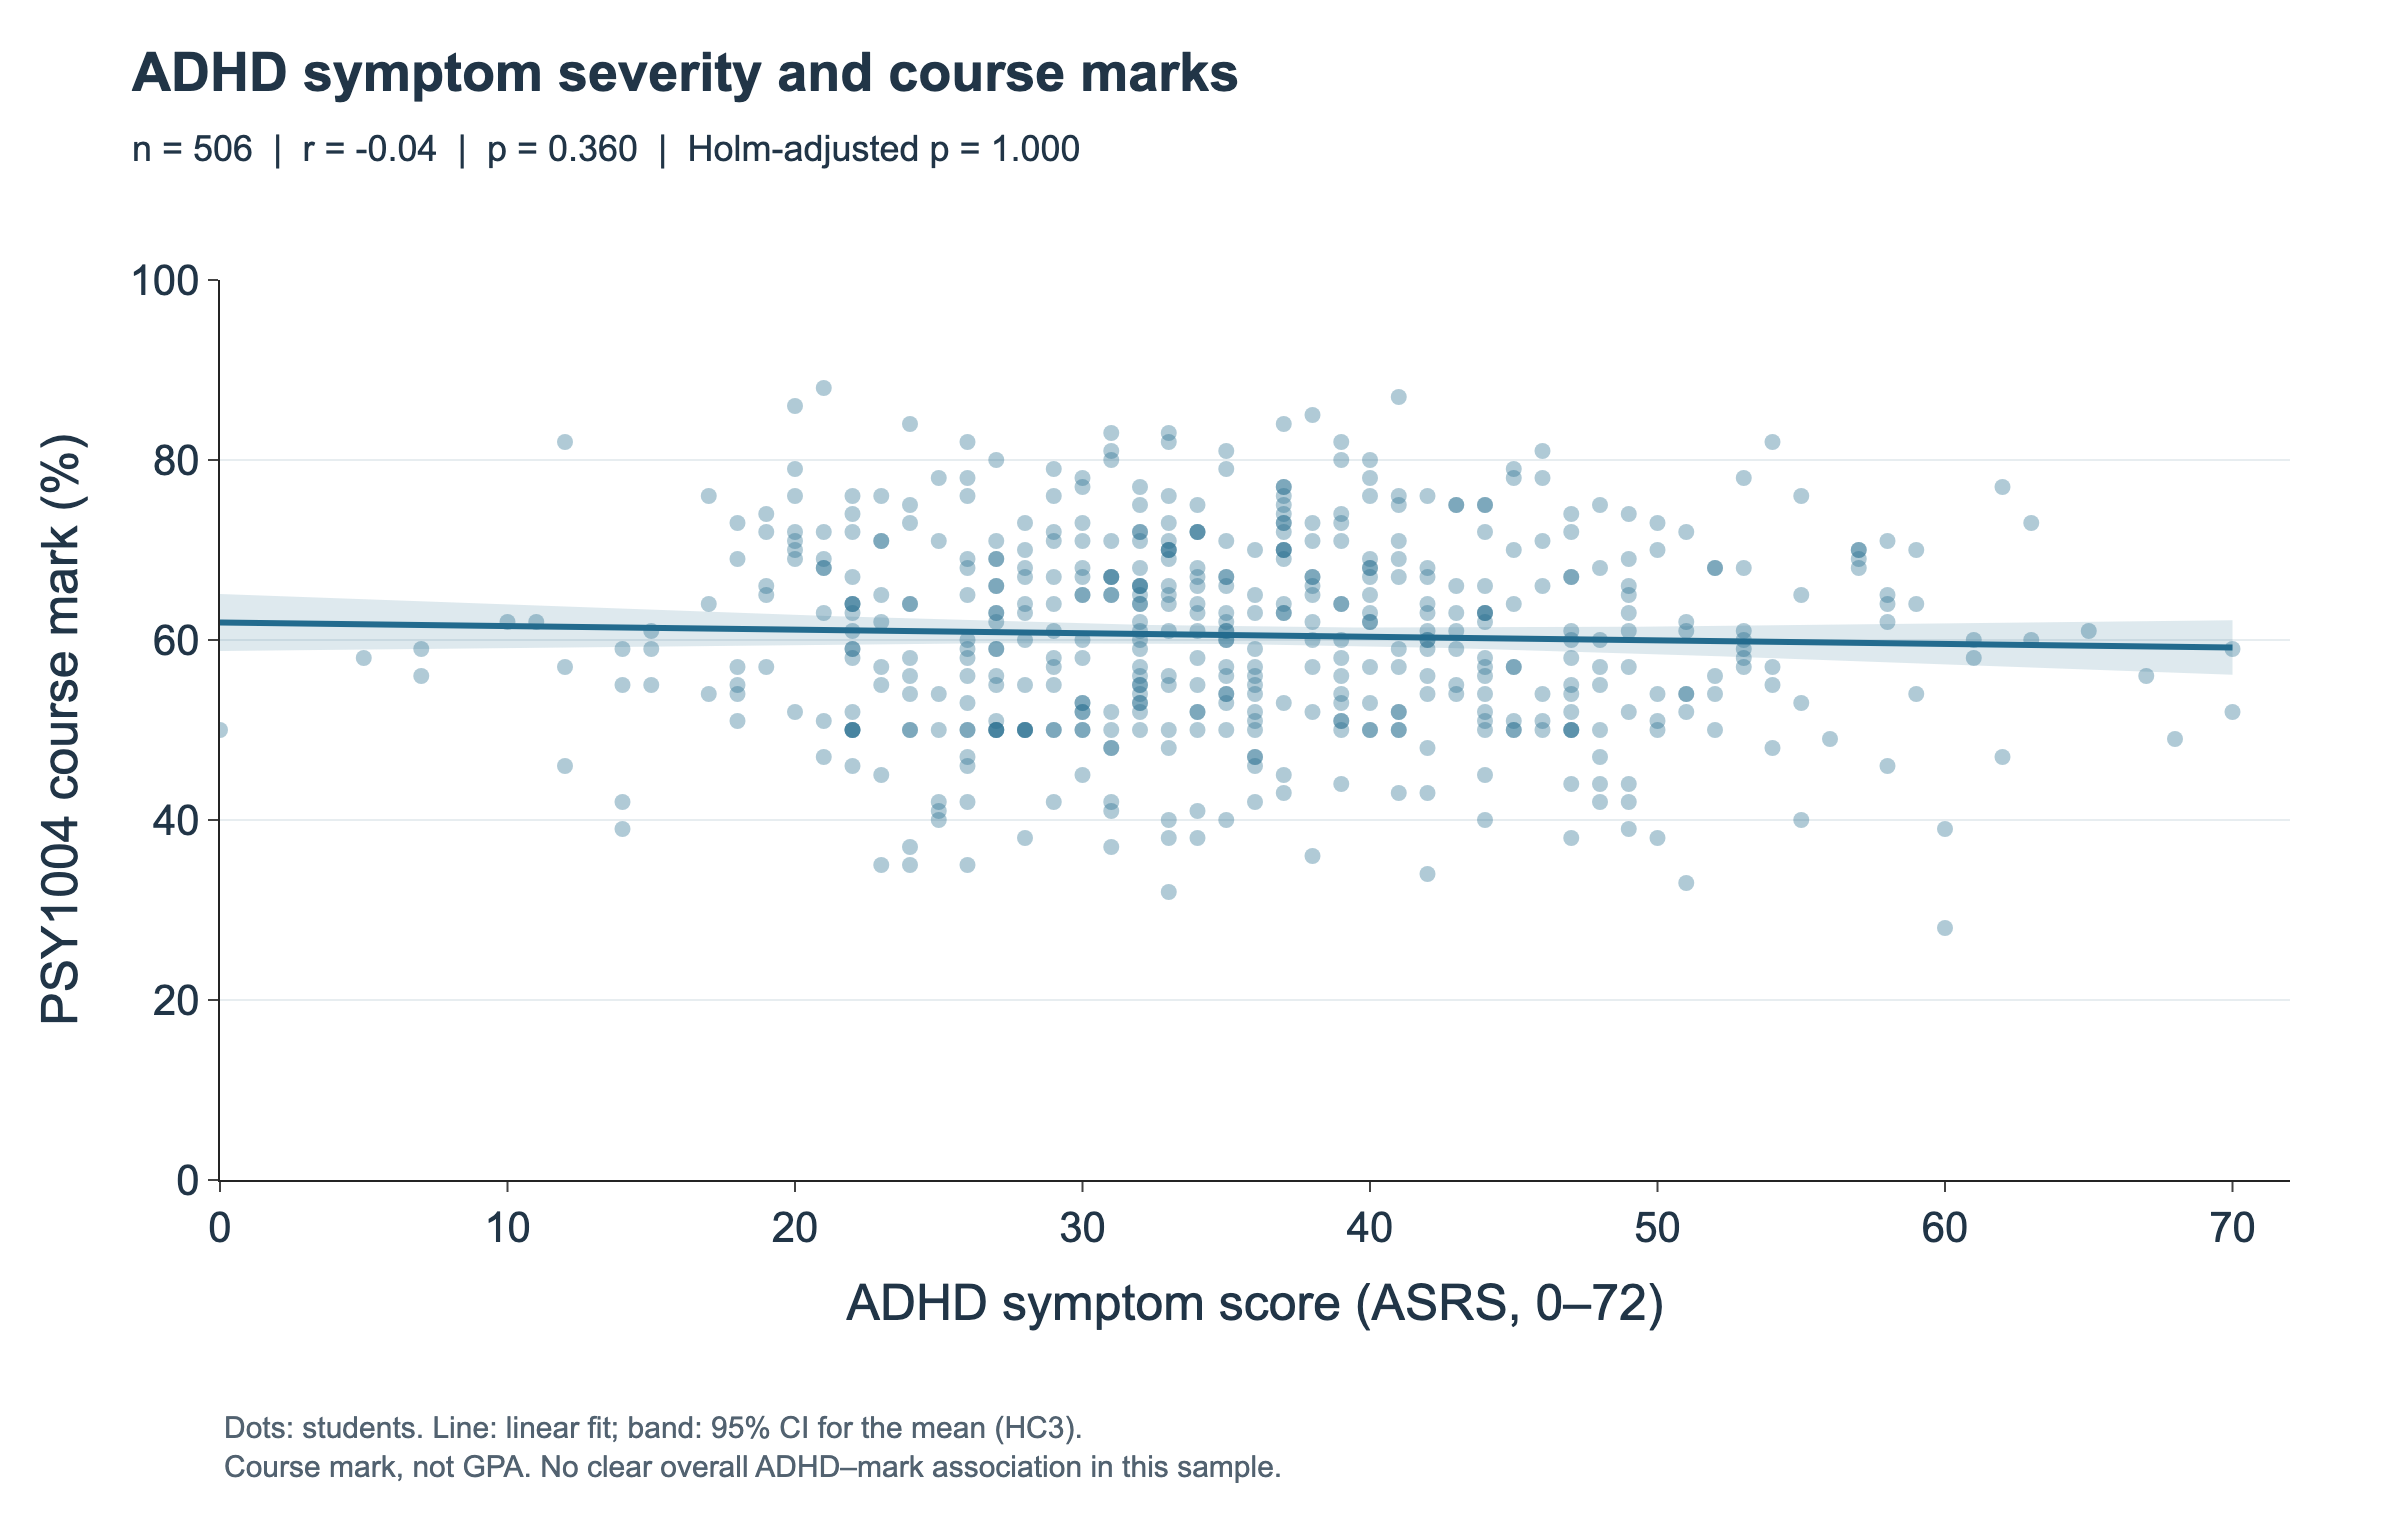

In [11]:
png_path = ROOT / "outputs/adhd_severity_vs_academic_performance.png"
if png_path.exists():
    display(Image(filename=str(png_path), width=1000))
else:
    display(figures["adhd_severity_vs_academic_performance"])

### B. Inattention and course marks

[Open interactive graph](outputs/inattention_vs_academic_performance.html)

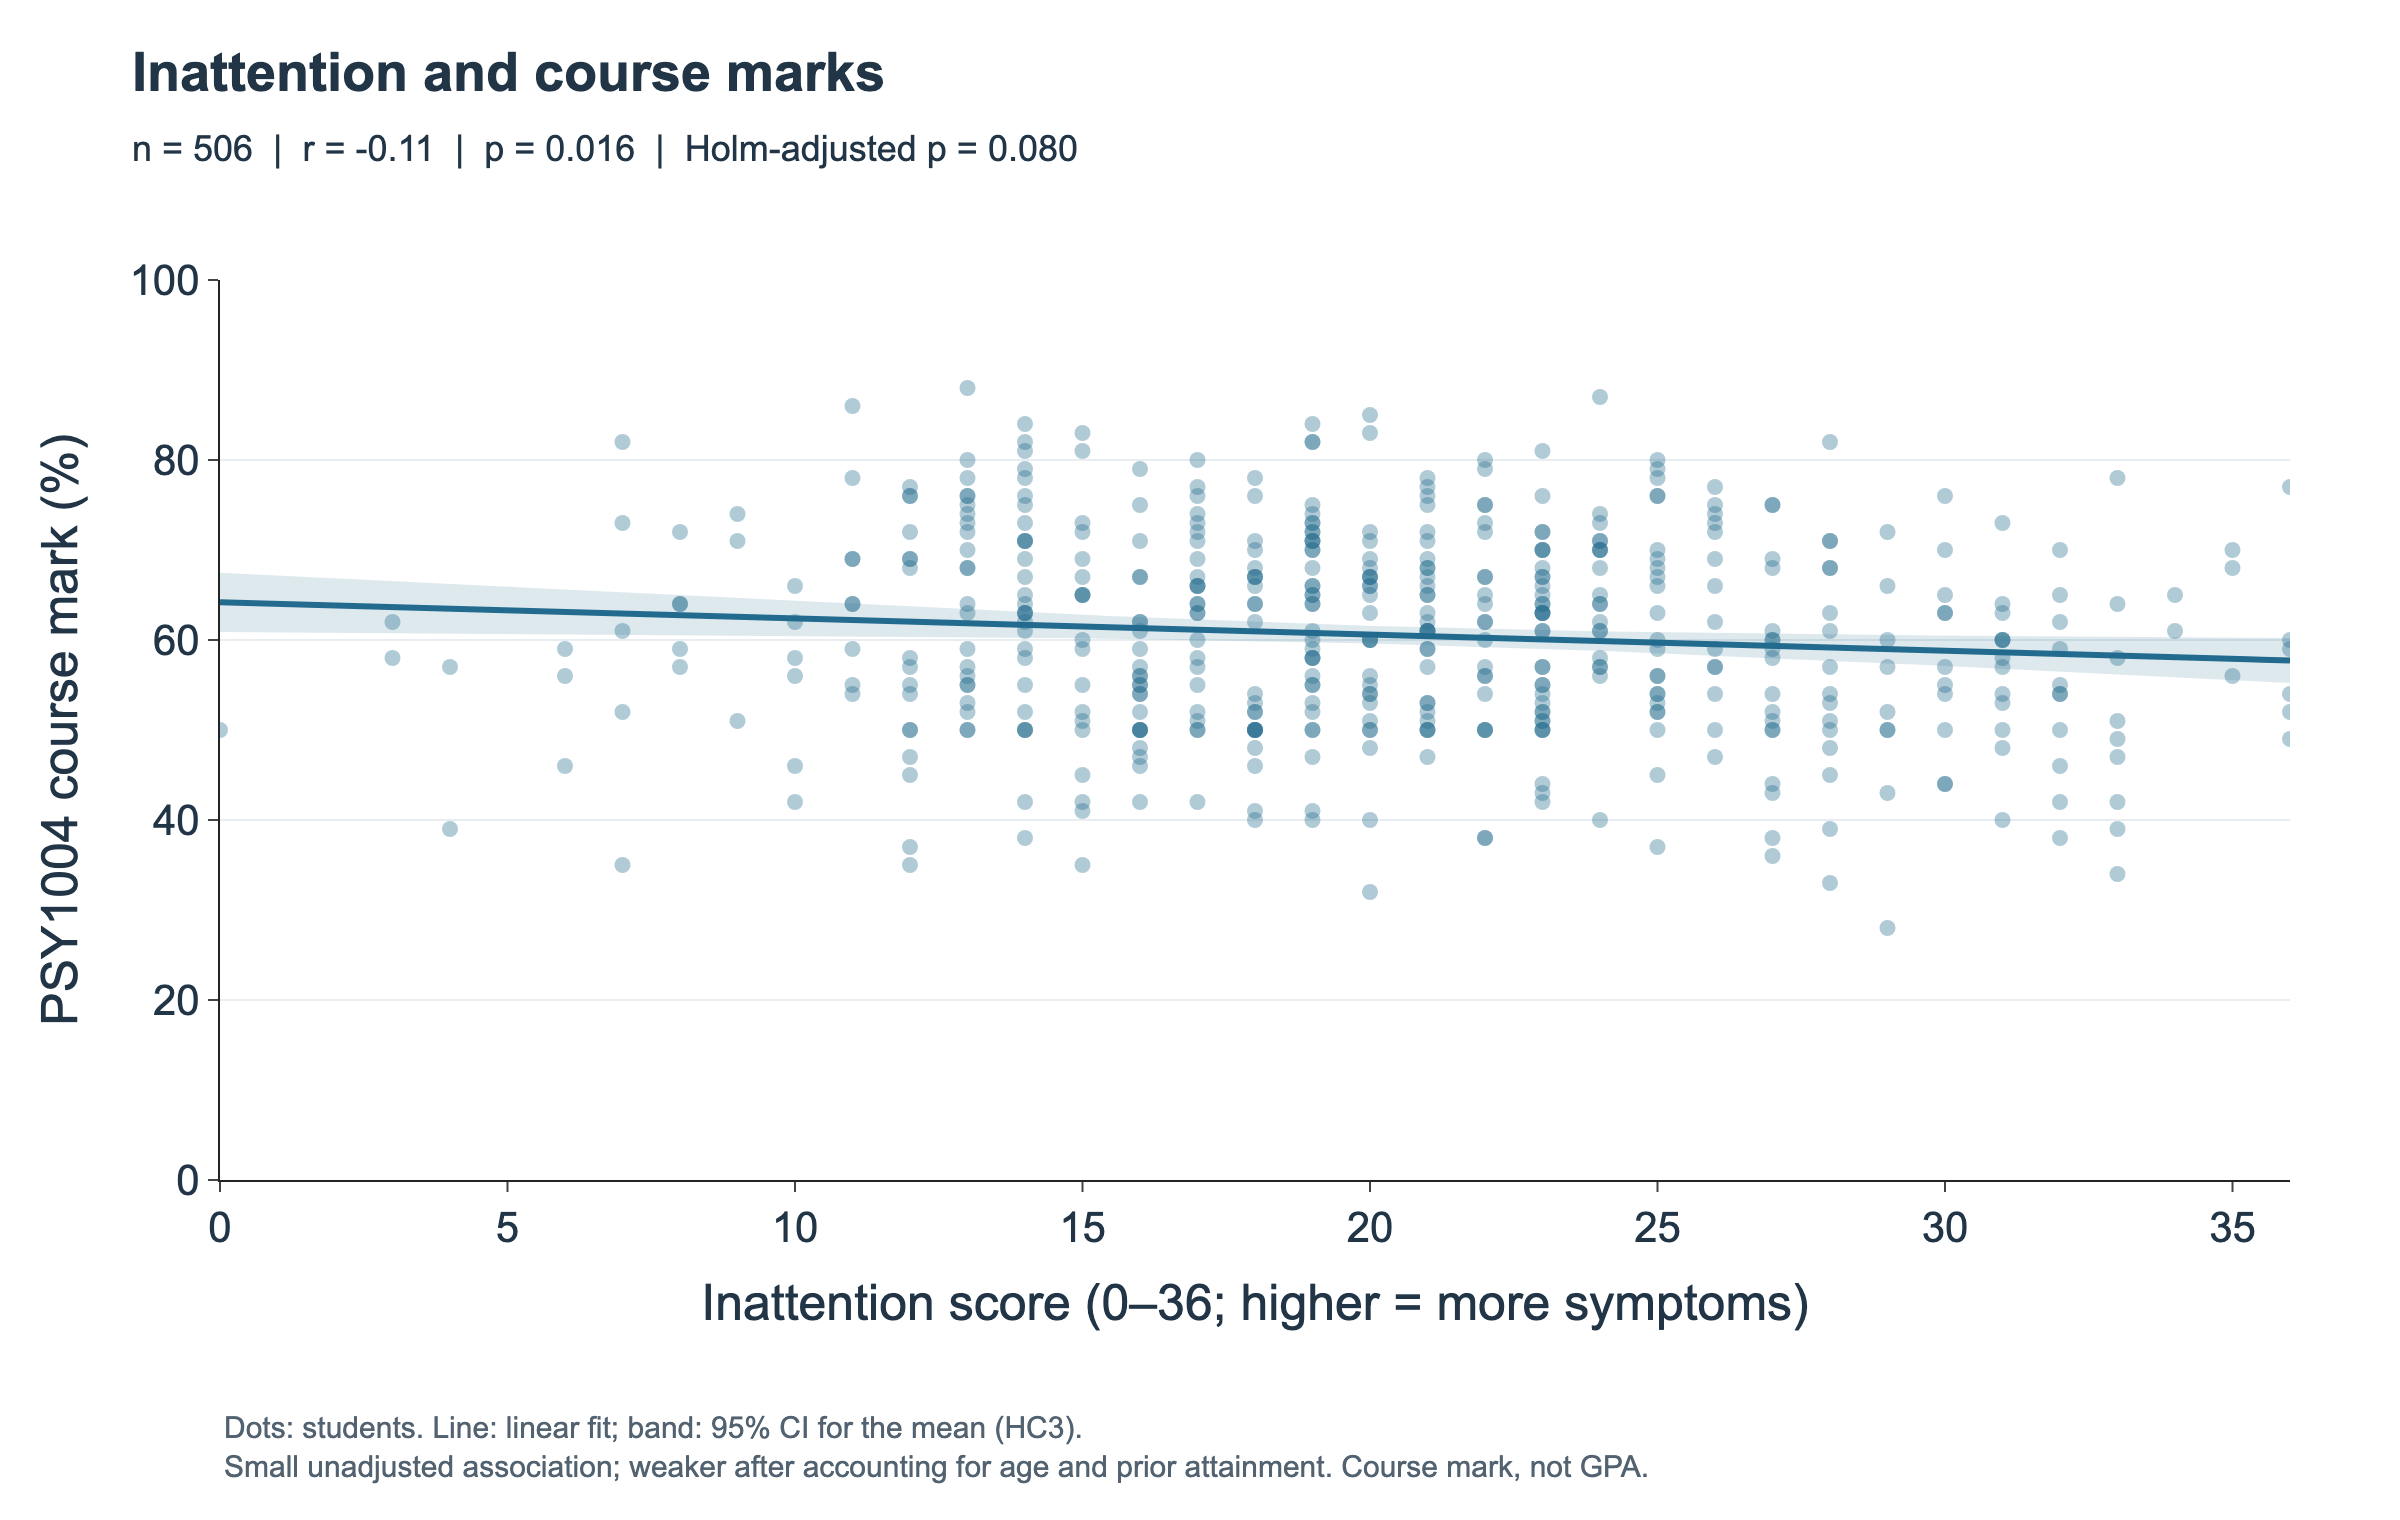

In [12]:
png_path = ROOT / "outputs/inattention_vs_academic_performance.png"
if png_path.exists():
    display(Image(filename=str(png_path), width=1000))
else:
    display(figures["inattention_vs_academic_performance"])

### C. Overall ADHD symptoms and academic adjustment

[Open interactive graph](outputs/adhd_vs_academic_adjustment.html)

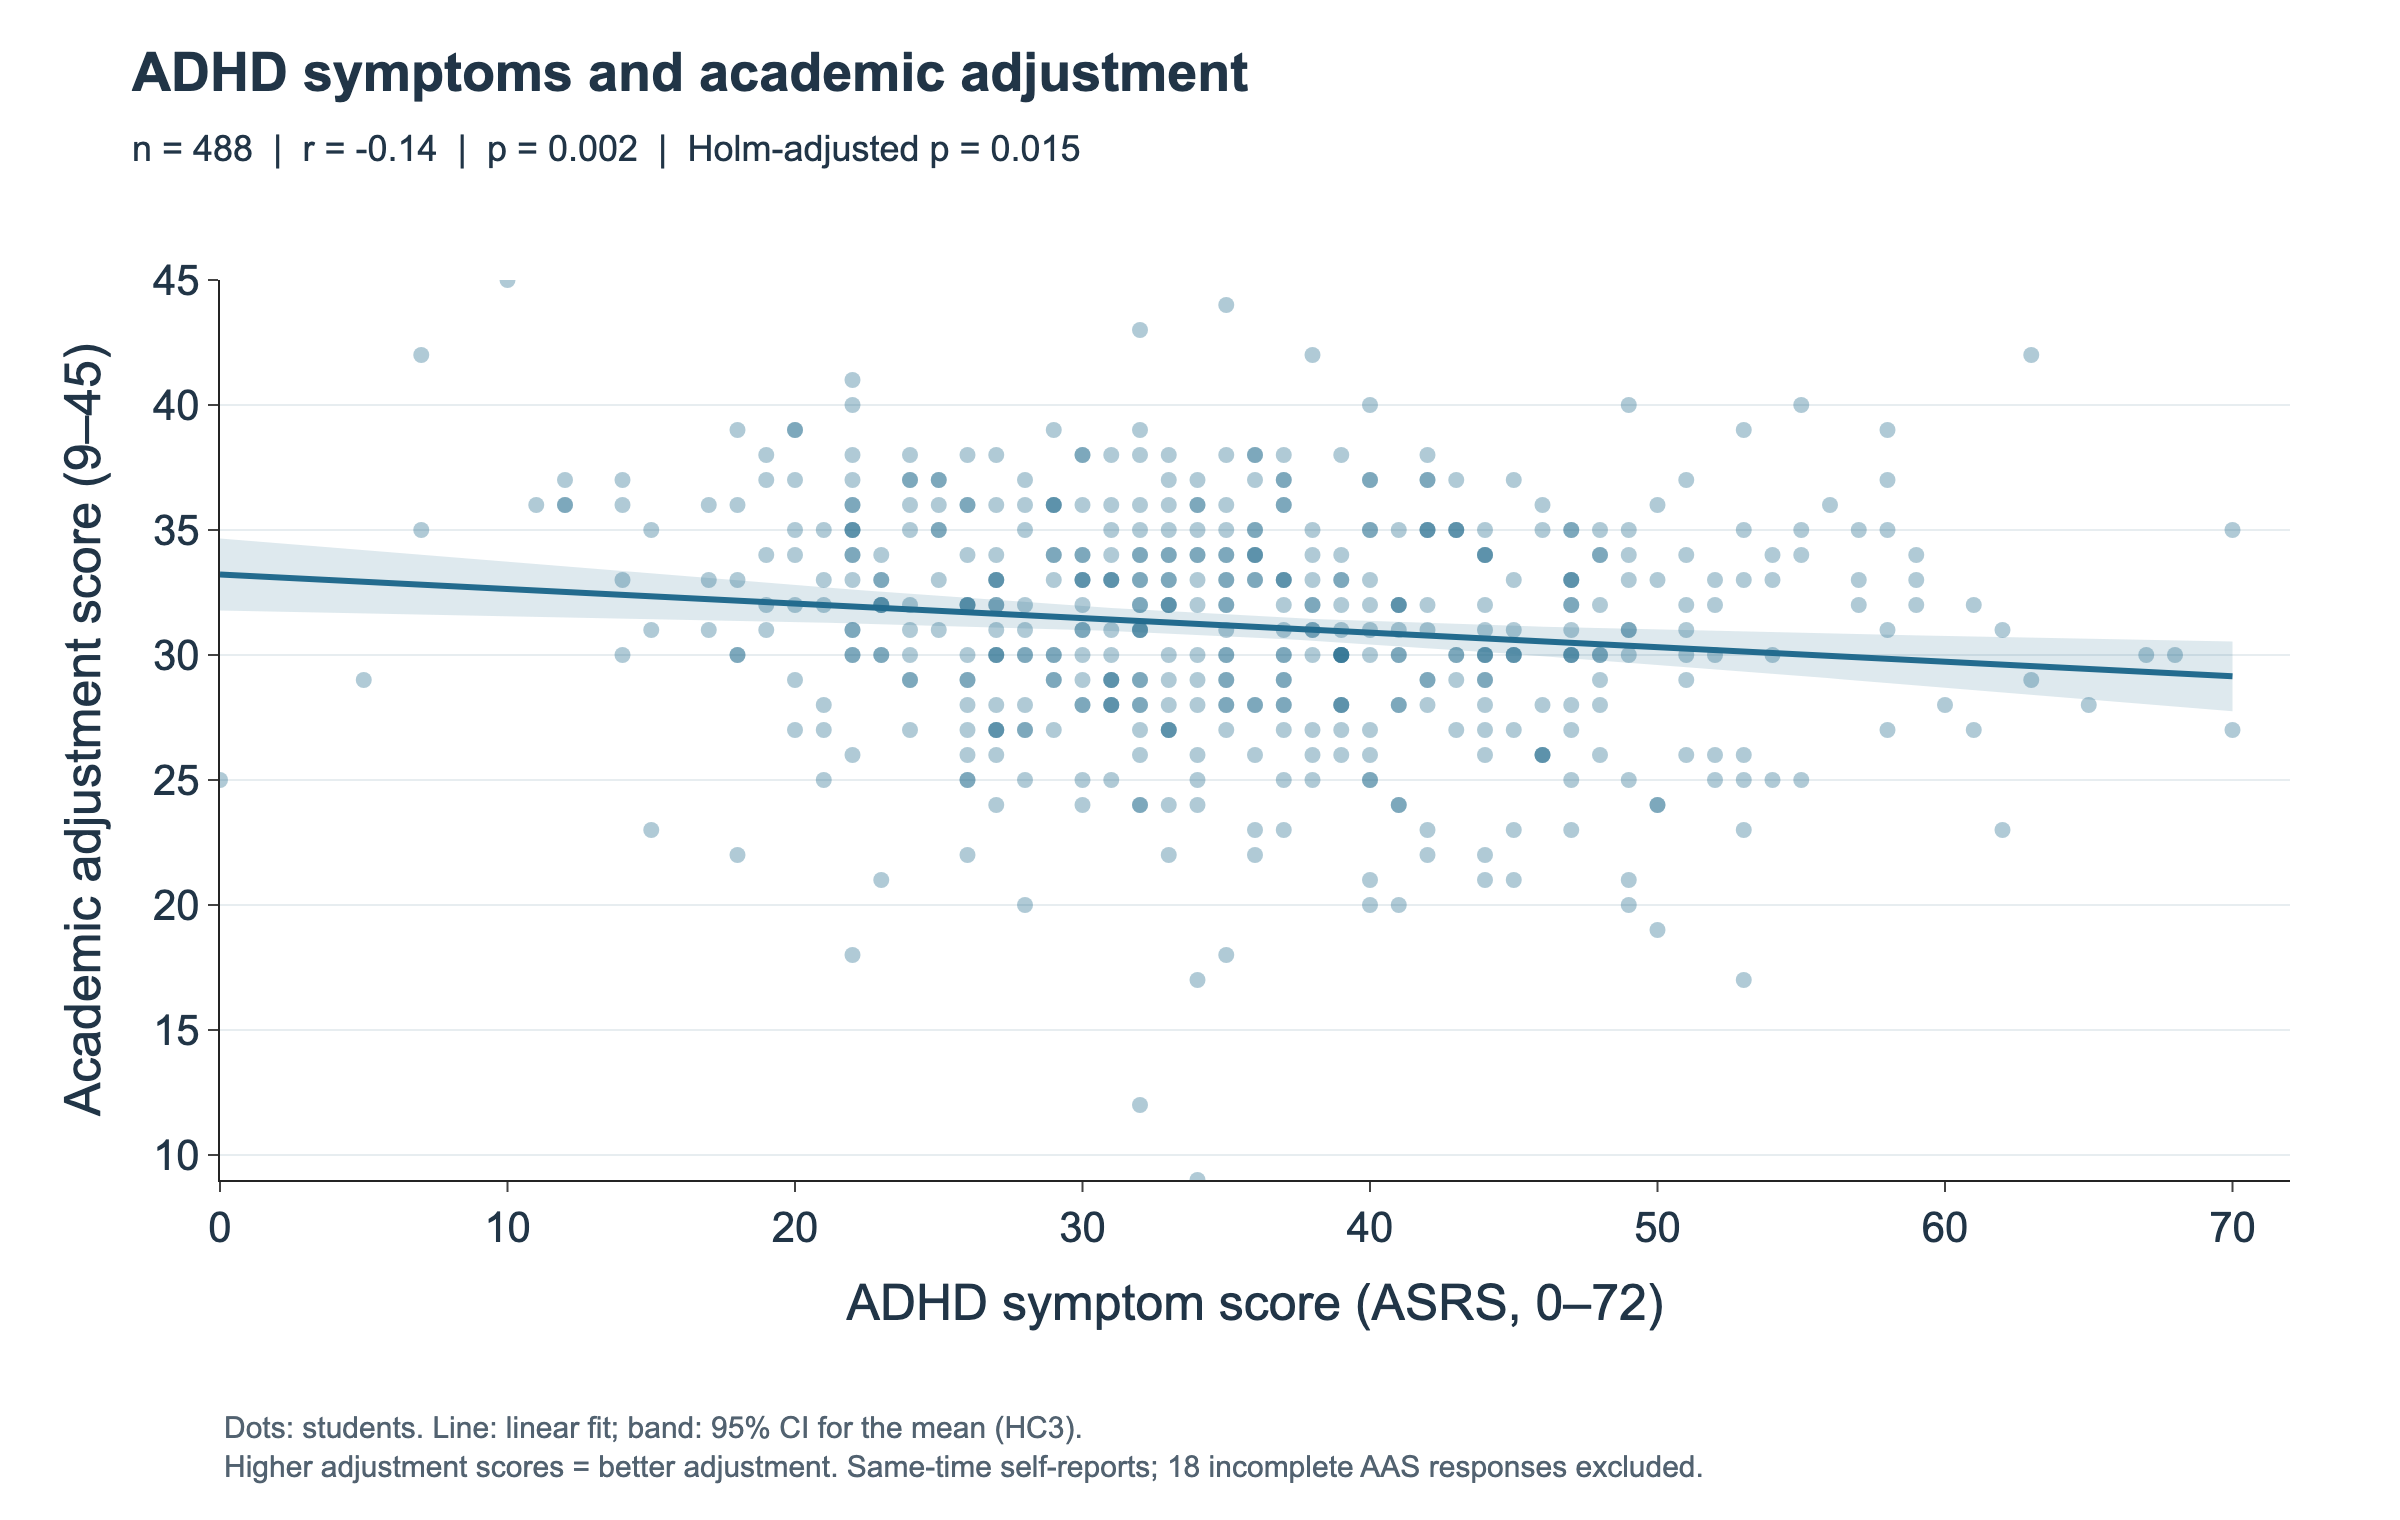

In [13]:
png_path = ROOT / "outputs/adhd_vs_academic_adjustment.png"
if png_path.exists():
    display(Image(filename=str(png_path), width=1000))
else:
    display(figures["adhd_vs_academic_adjustment"])

### C. Inattention and academic adjustment

[Open interactive graph](outputs/inattention_vs_academic_adjustment.html)

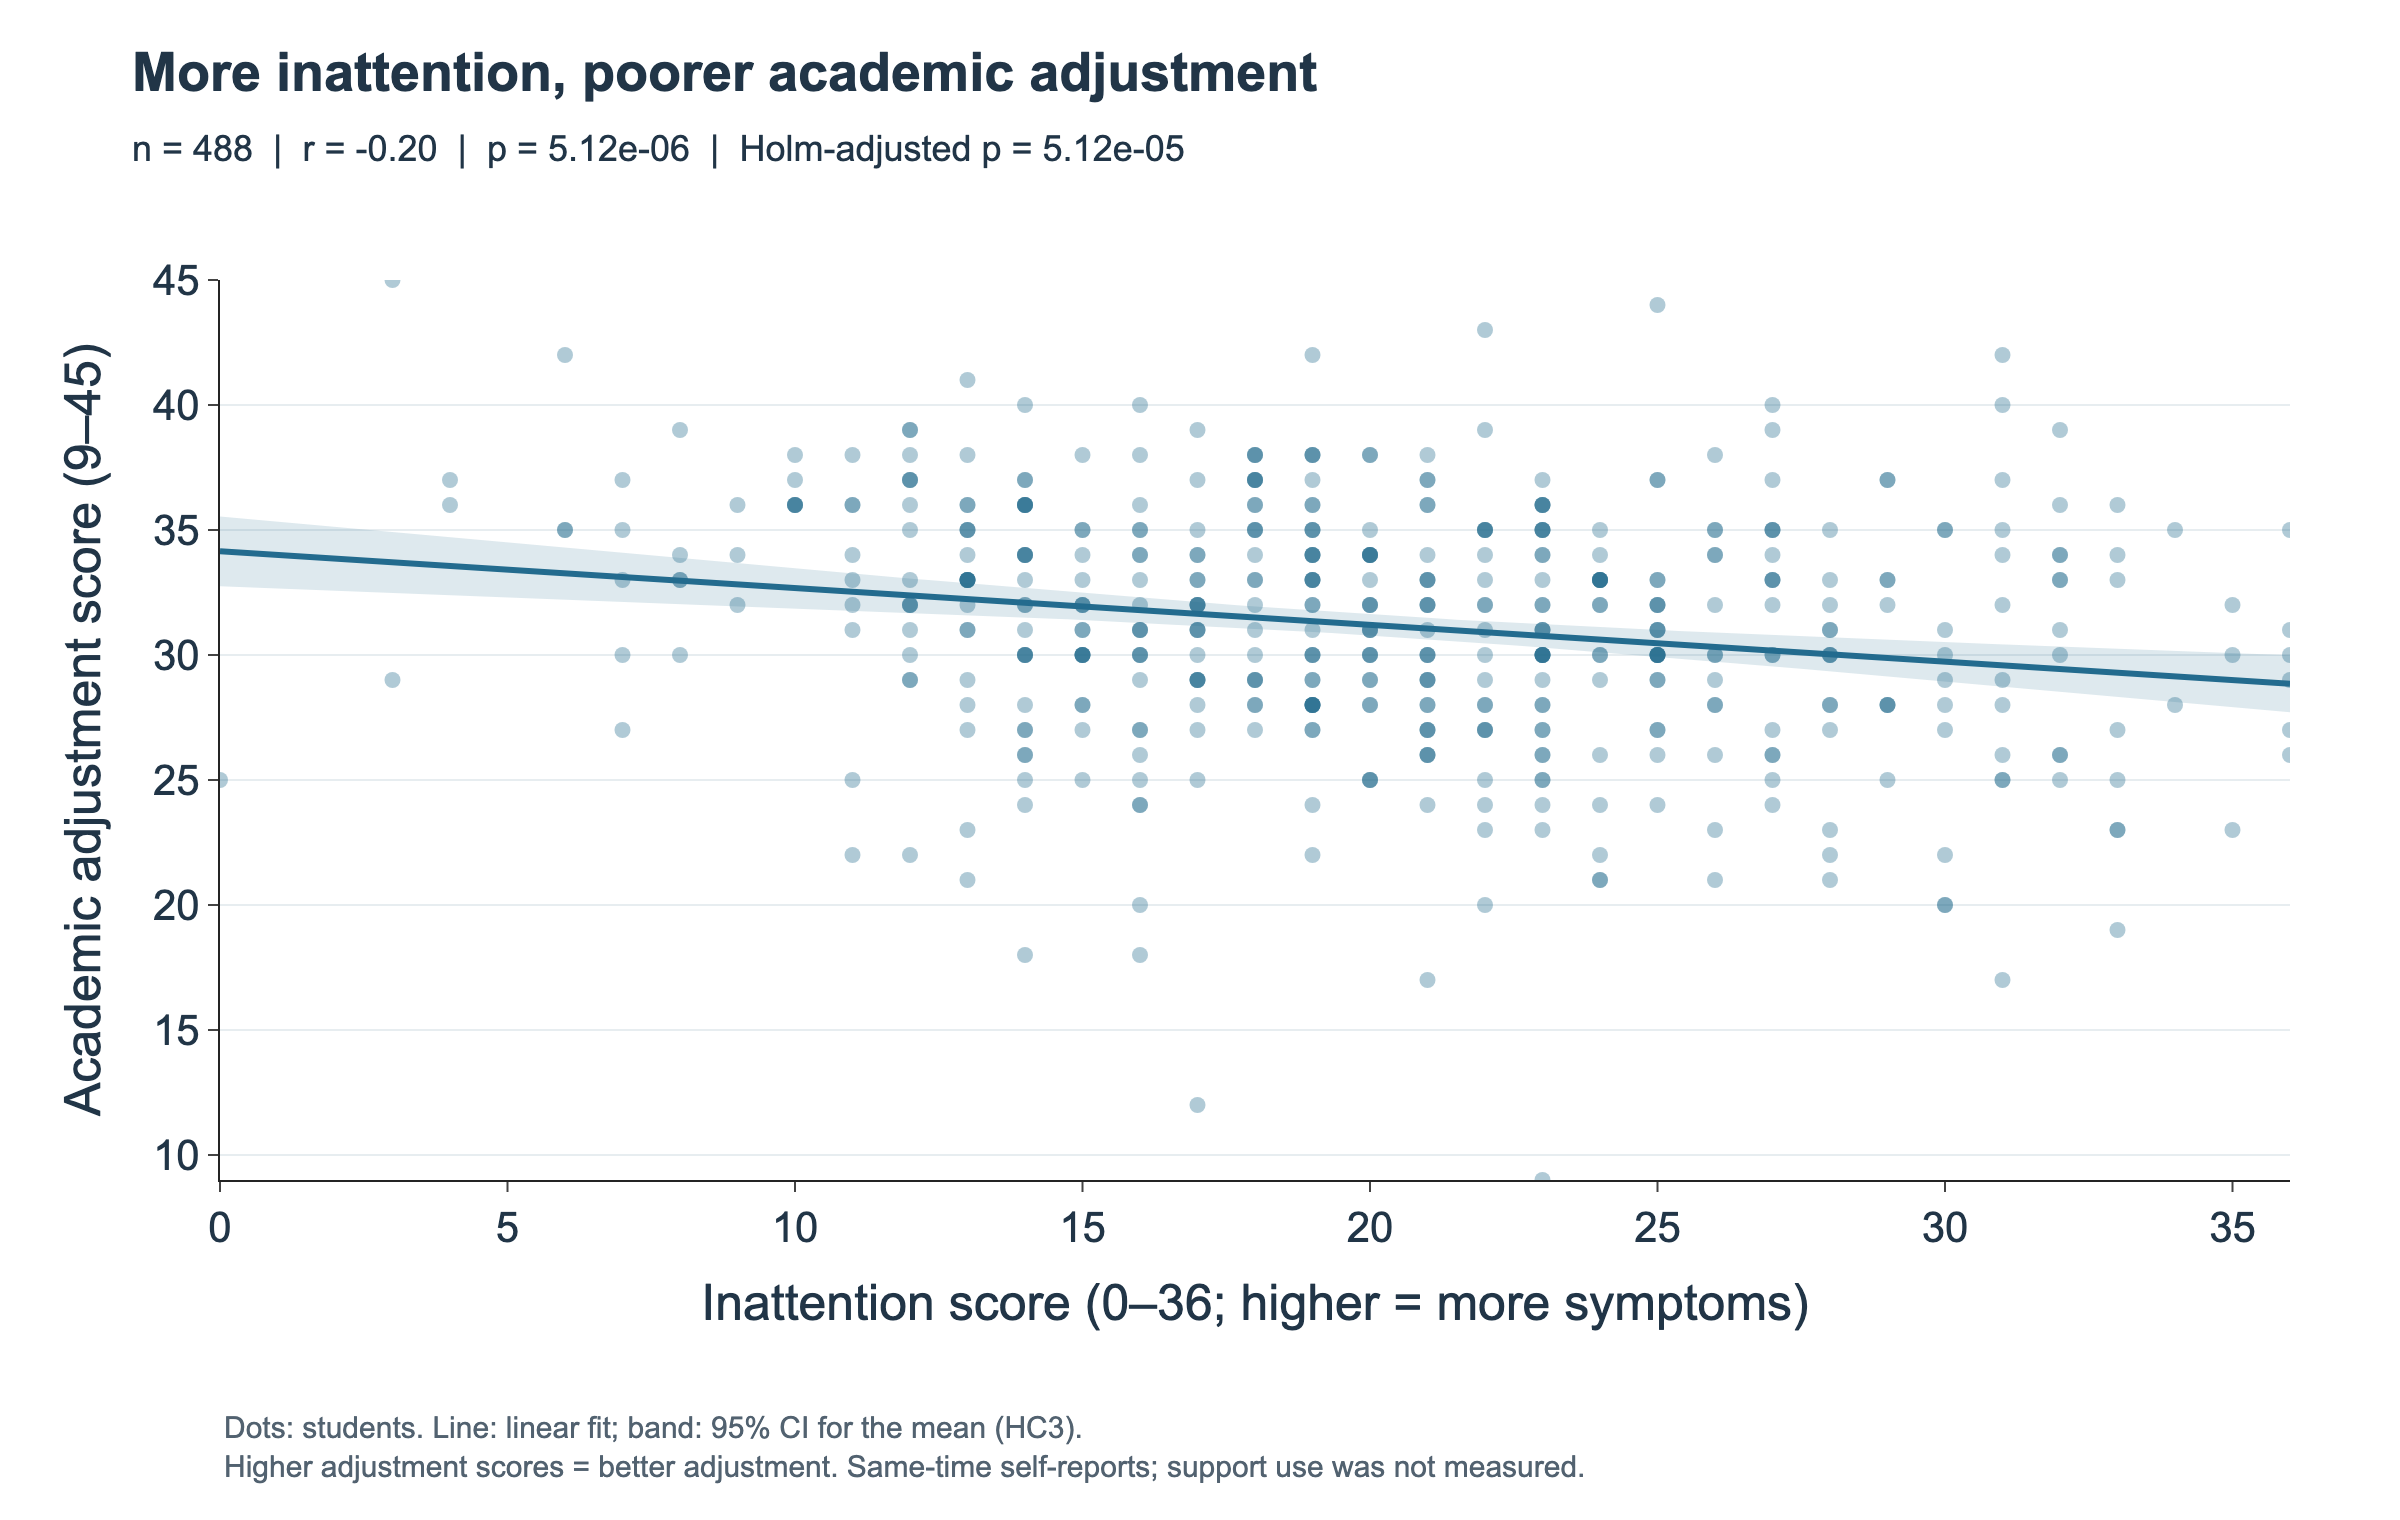

In [14]:
png_path = ROOT / "outputs/inattention_vs_academic_adjustment.png"
if png_path.exists():
    display(Image(filename=str(png_path), width=1000))
else:
    display(figures["inattention_vs_academic_adjustment"])

### D. ADHD screening groups and course marks

[Open interactive graph](outputs/adhd_screening_vs_academic_performance.html)

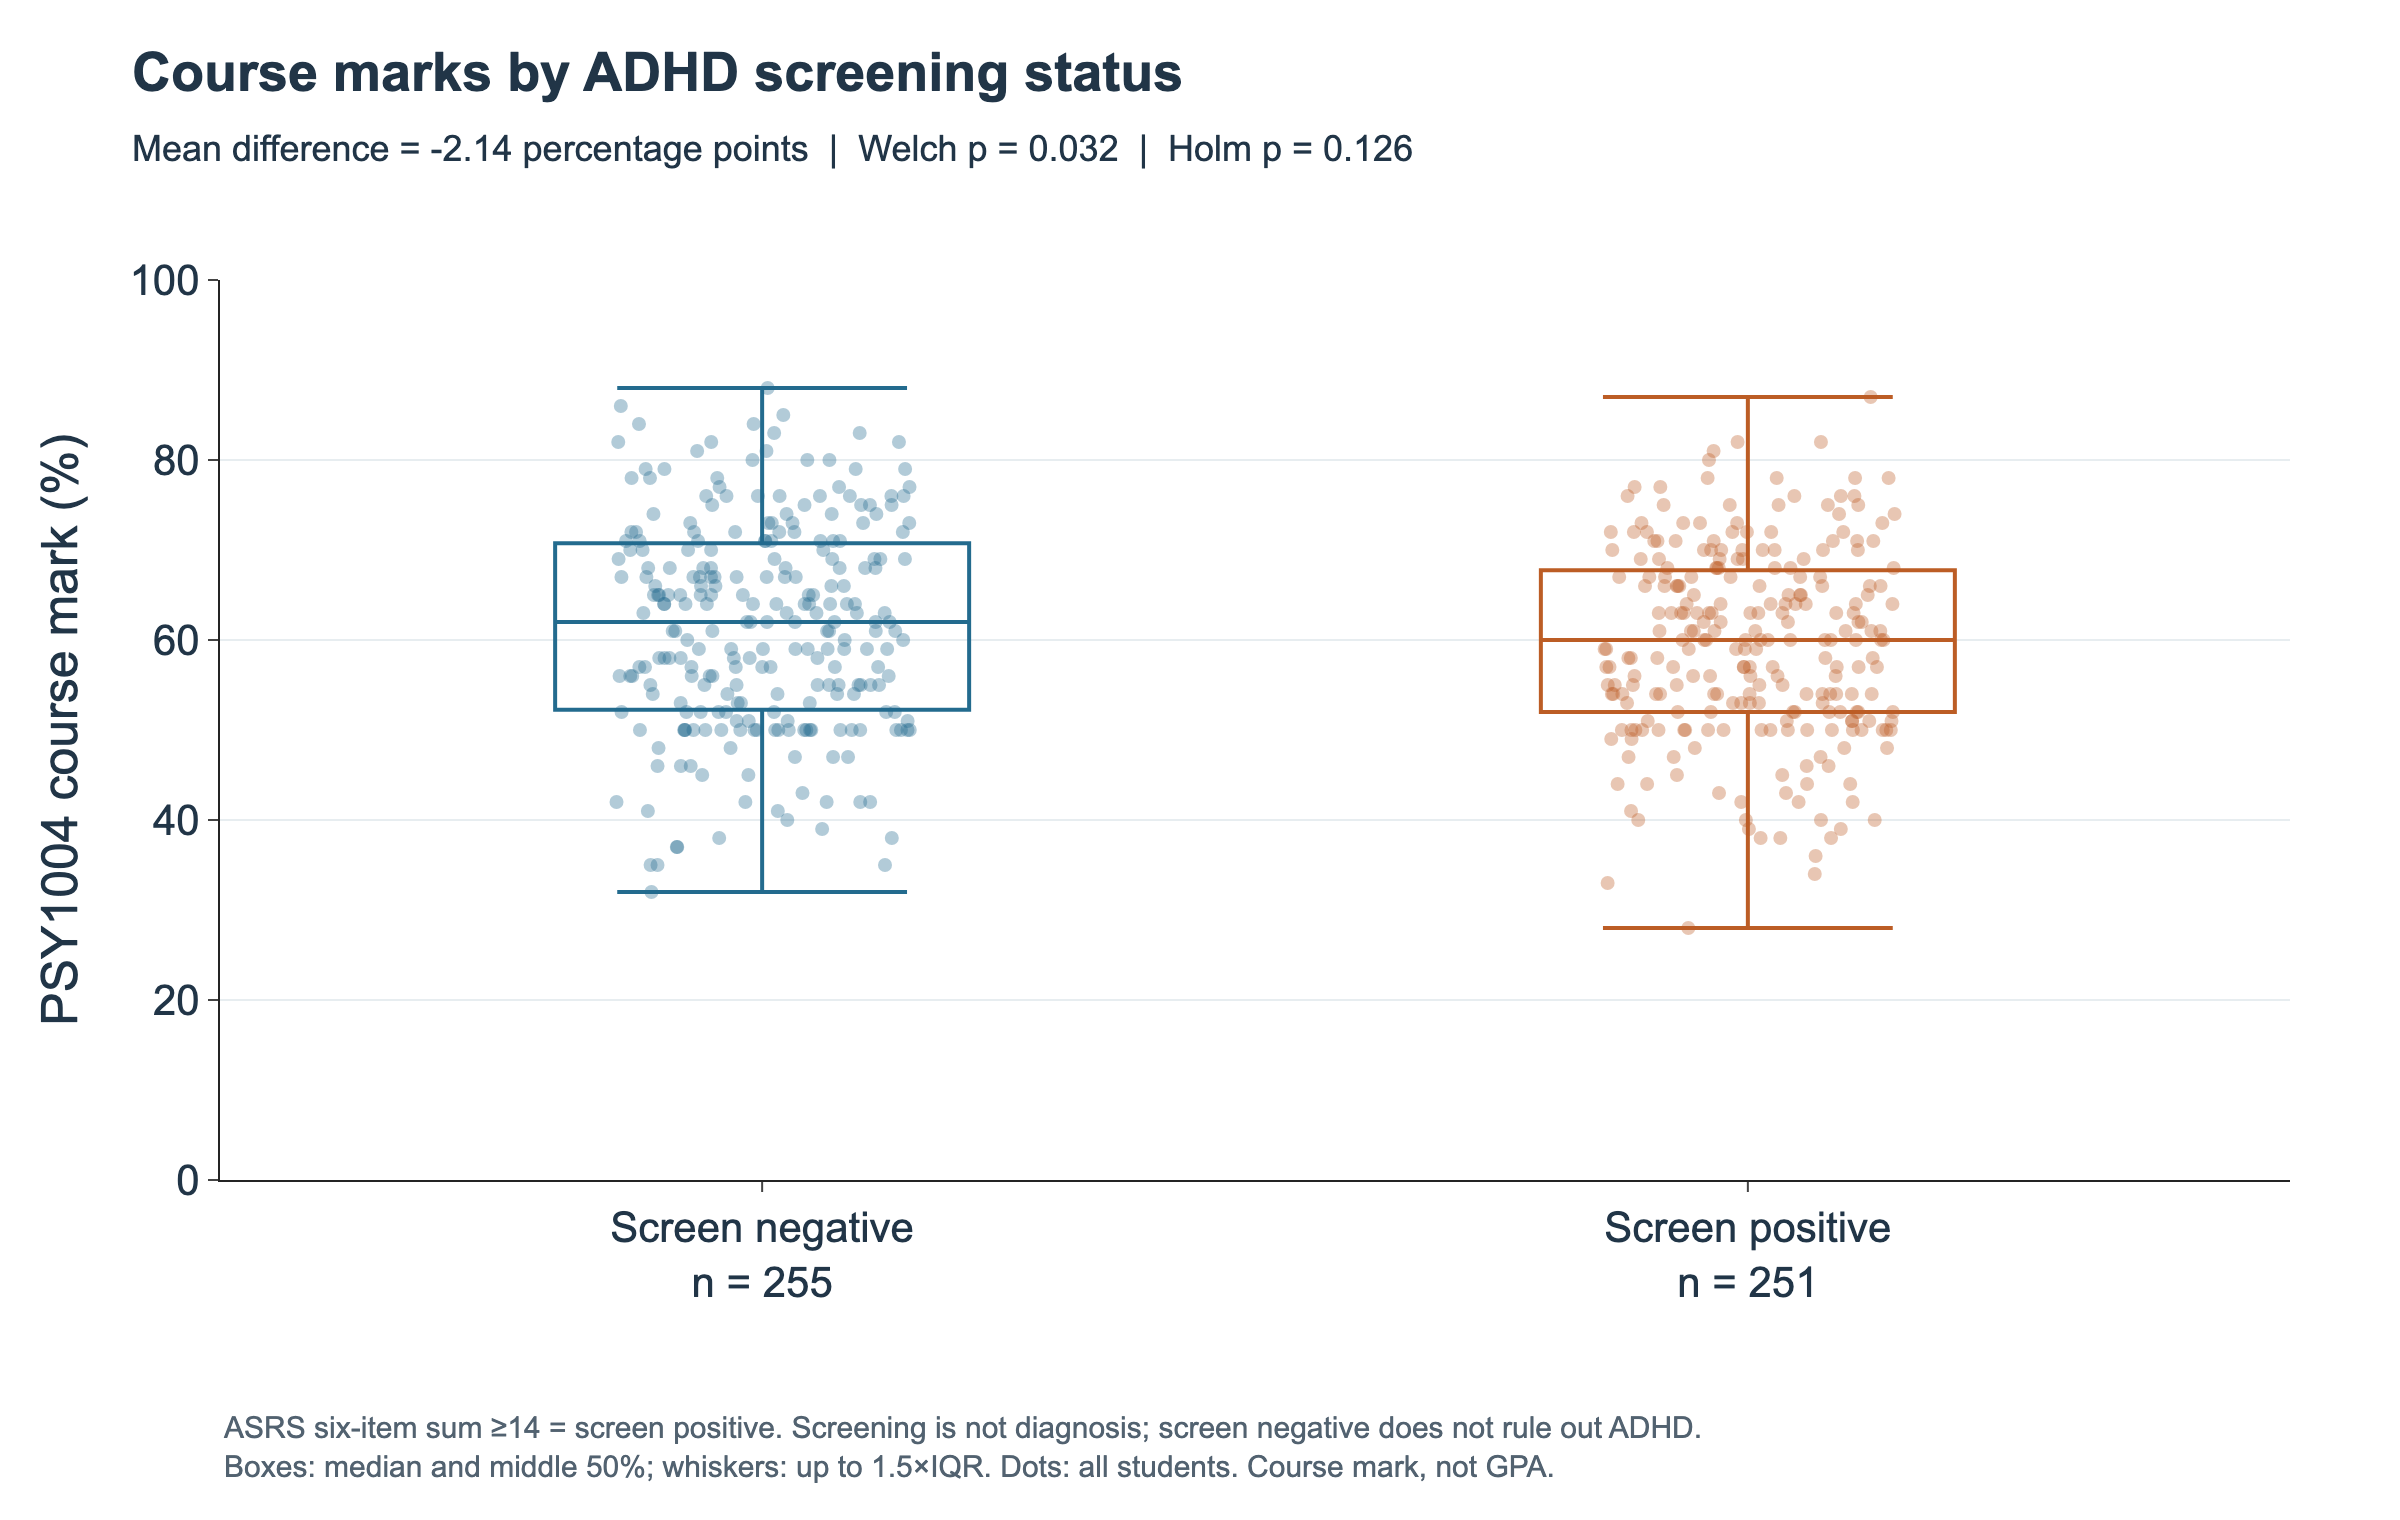

In [15]:
png_path = ROOT / "outputs/adhd_screening_vs_academic_performance.png"
if png_path.exists():
    display(Image(filename=str(png_path), width=1000))
else:
    display(figures["adhd_screening_vs_academic_performance"])

### E. Symptom dimensions, with and without prior attainment

[Open interactive graph](outputs/symptom_dimensions_vs_academic_performance.html)

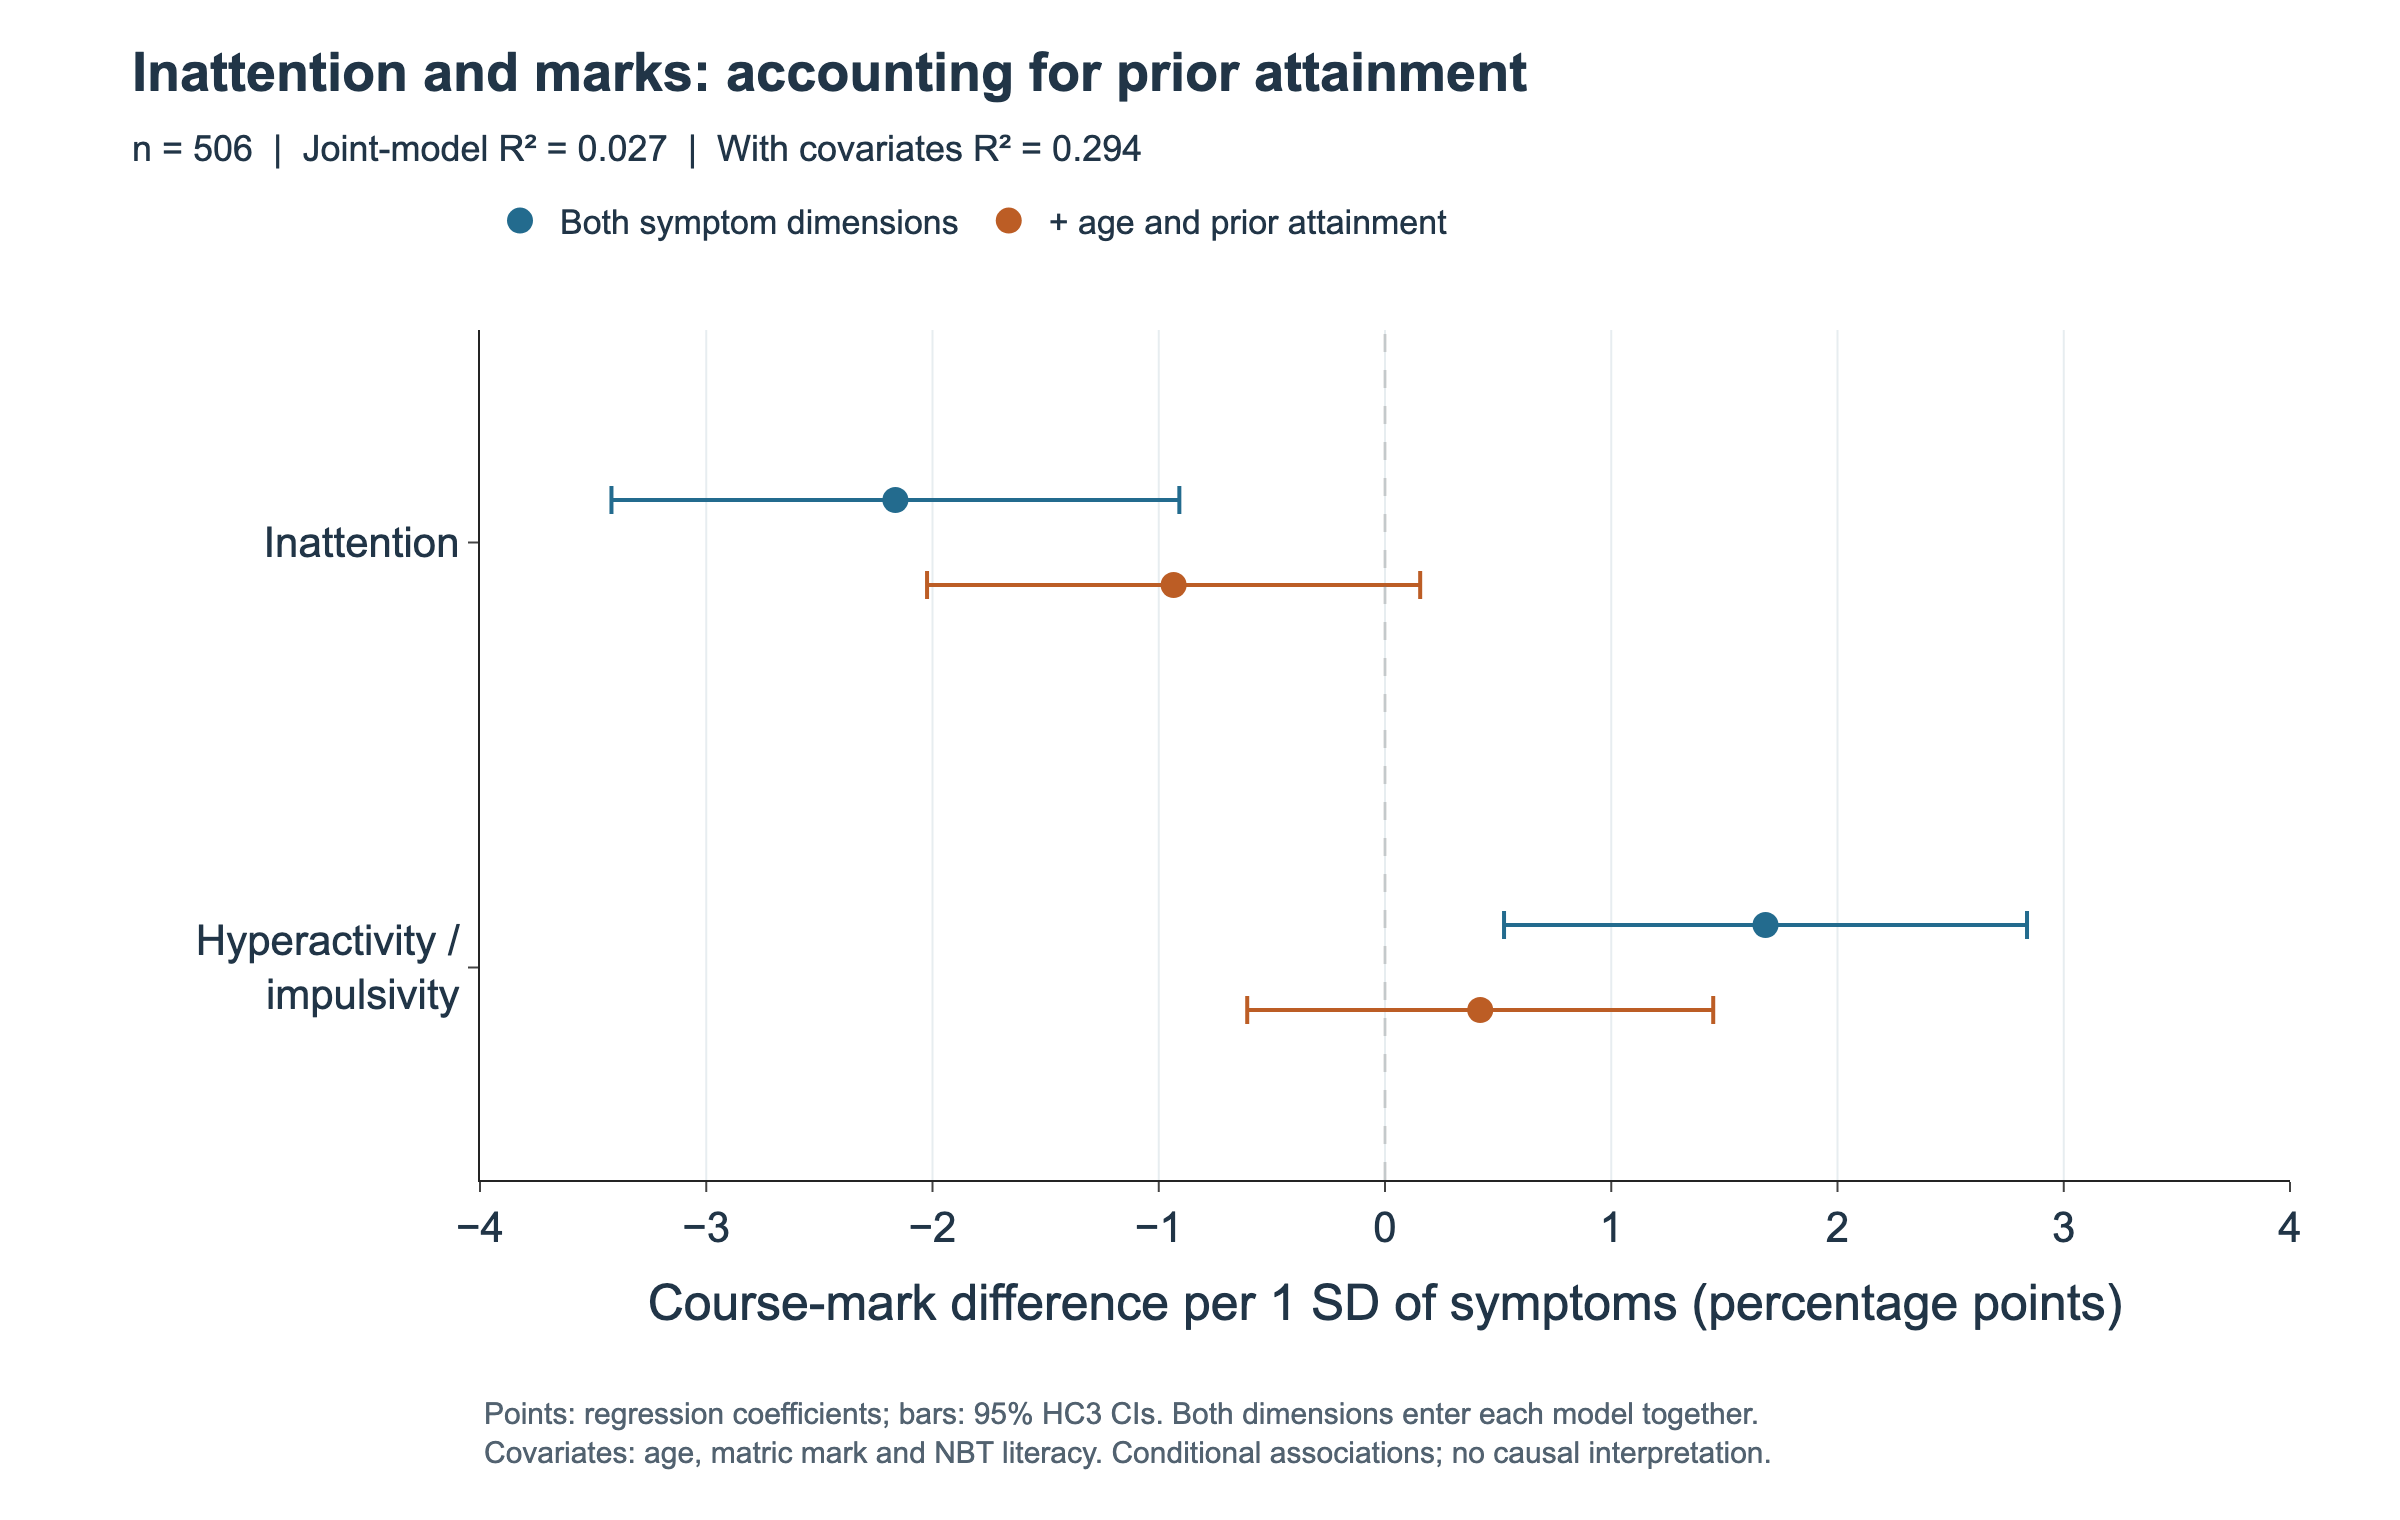

In [16]:
png_path = ROOT / "outputs/symptom_dimensions_vs_academic_performance.png"
if png_path.exists():
    display(Image(filename=str(png_path), width=1000))
else:
    display(figures["symptom_dimensions_vs_academic_performance"])

### Secondary: imported academic-adjustment change index

[Open interactive graph](outputs/inattention_vs_adjustment_change.html)

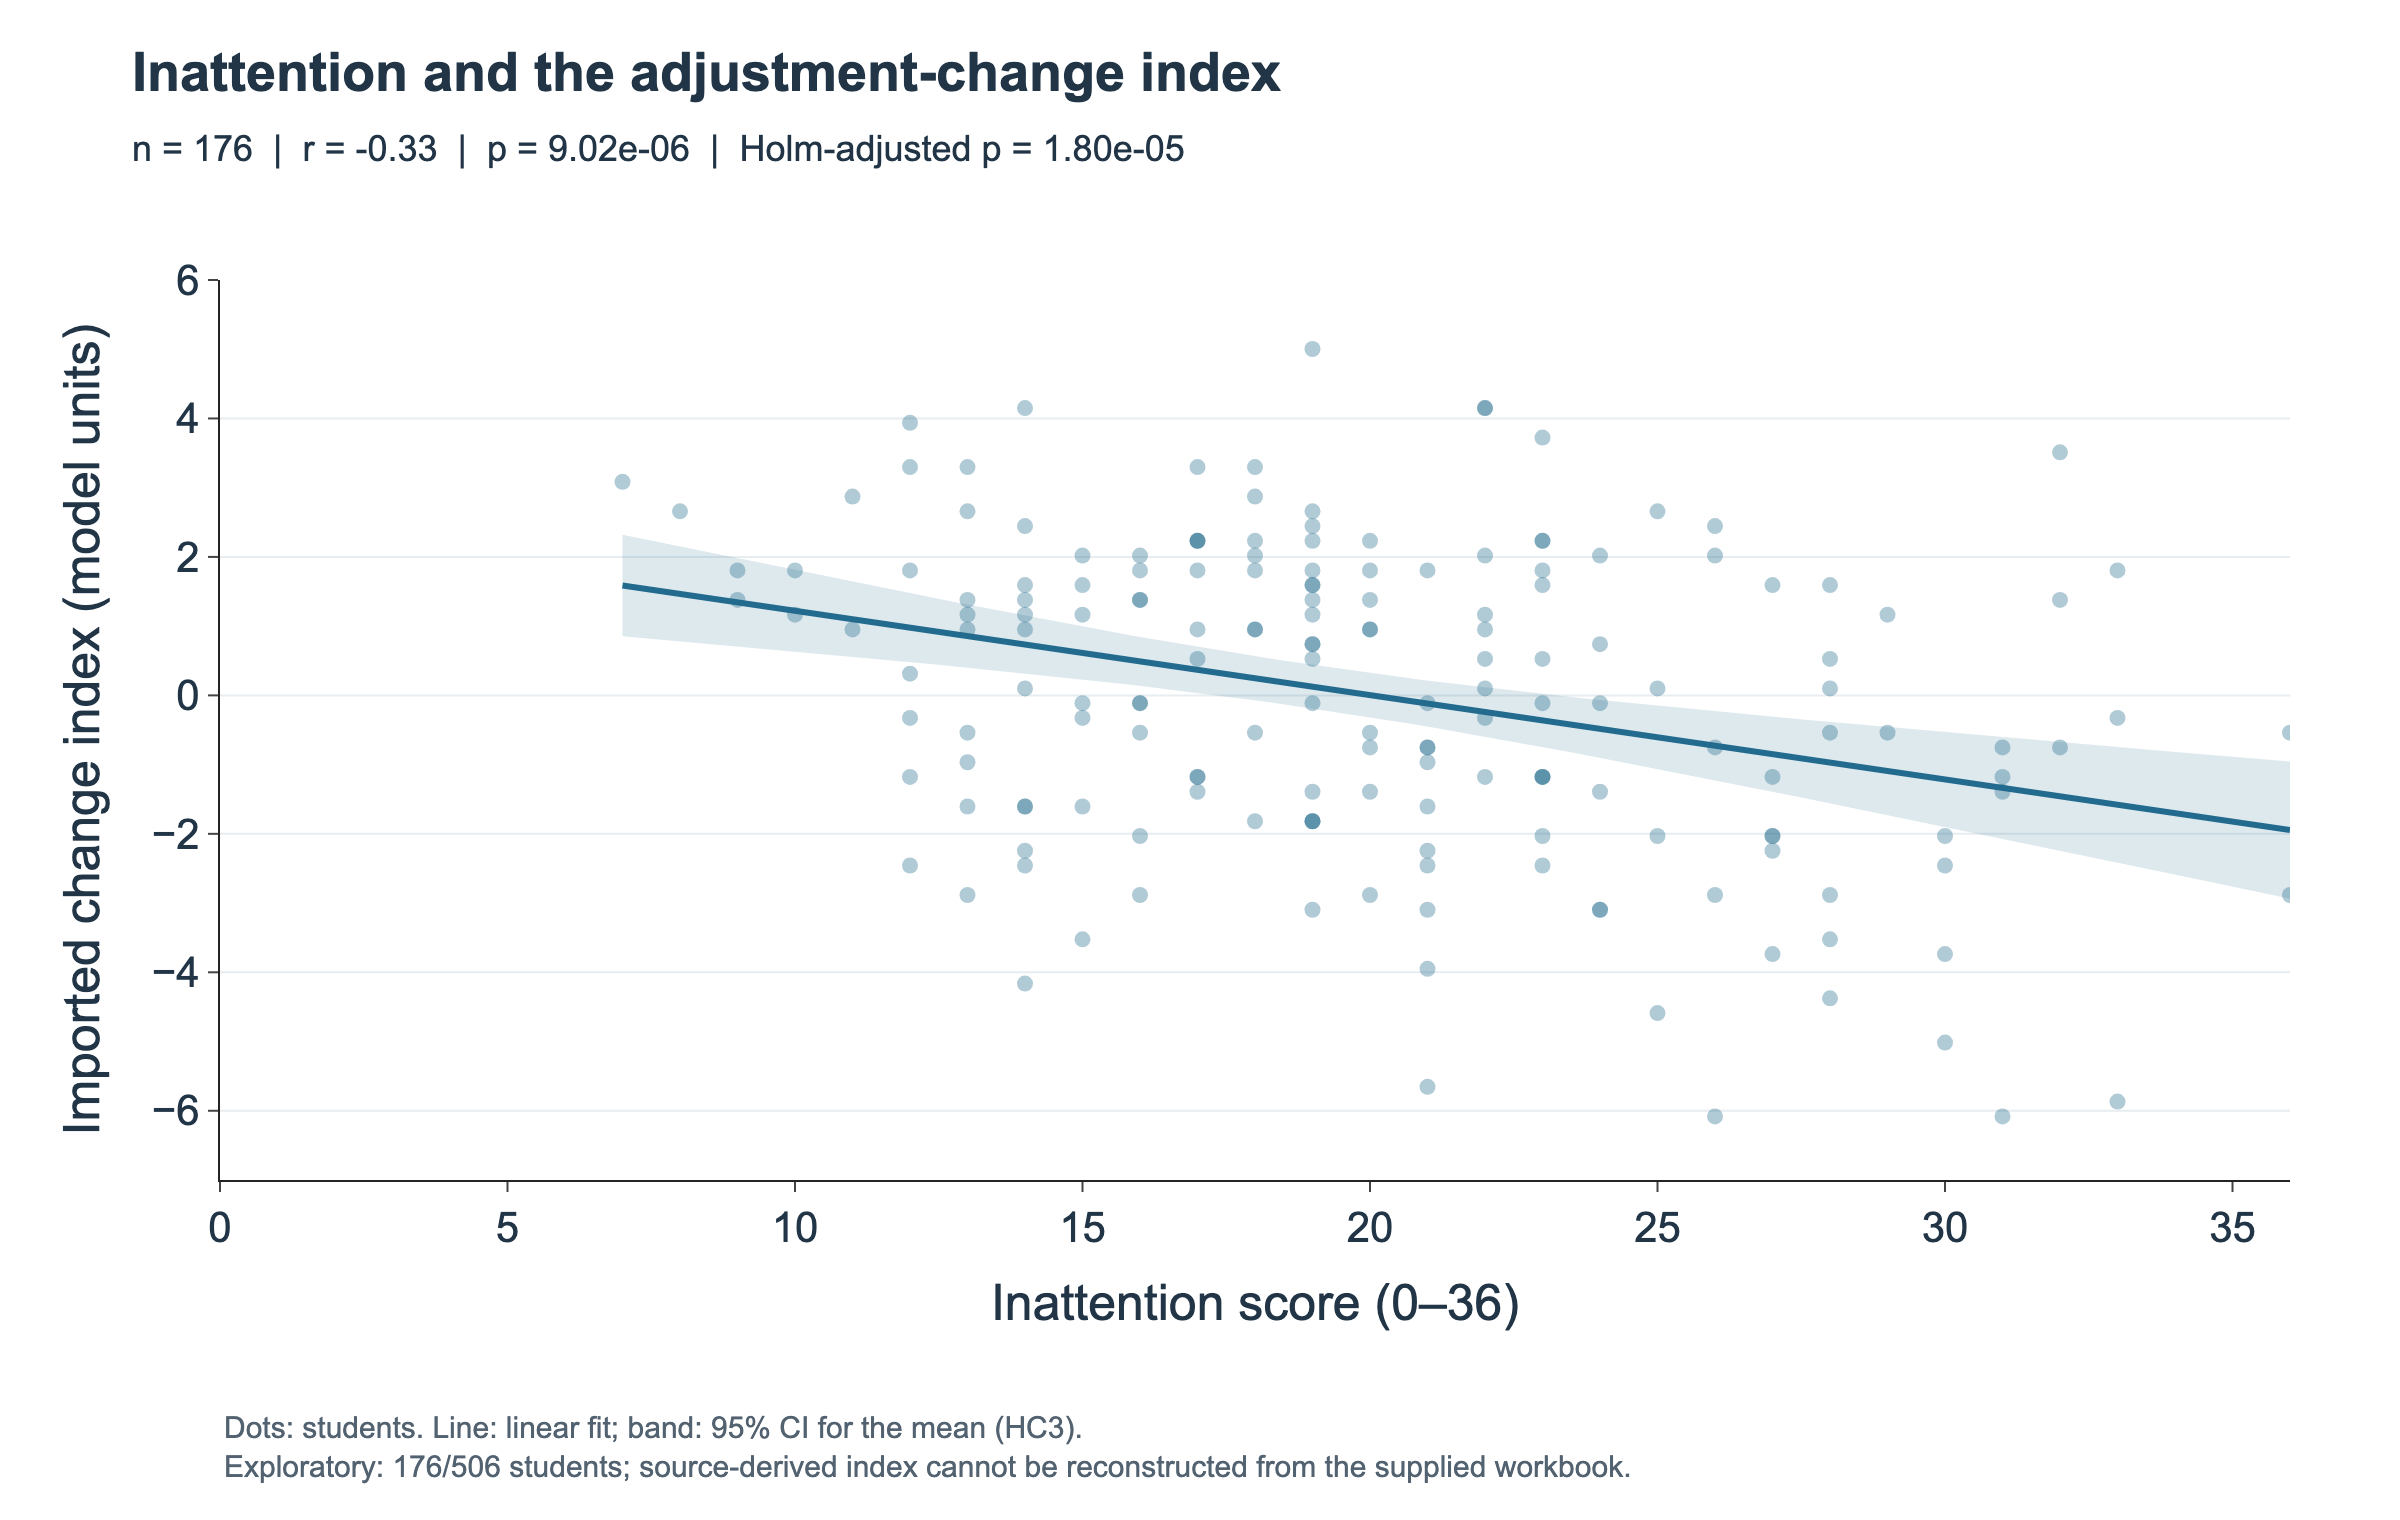

In [17]:
png_path = ROOT / "outputs/inattention_vs_adjustment_change.png"
if png_path.exists():
    display(Image(filename=str(png_path), width=1000))
else:
    display(figures["inattention_vs_adjustment_change"])

### Secondary: overlap with depressive and anxiety symptoms

[Open interactive graph](outputs/inattention_and_mental_health_symptoms.html)

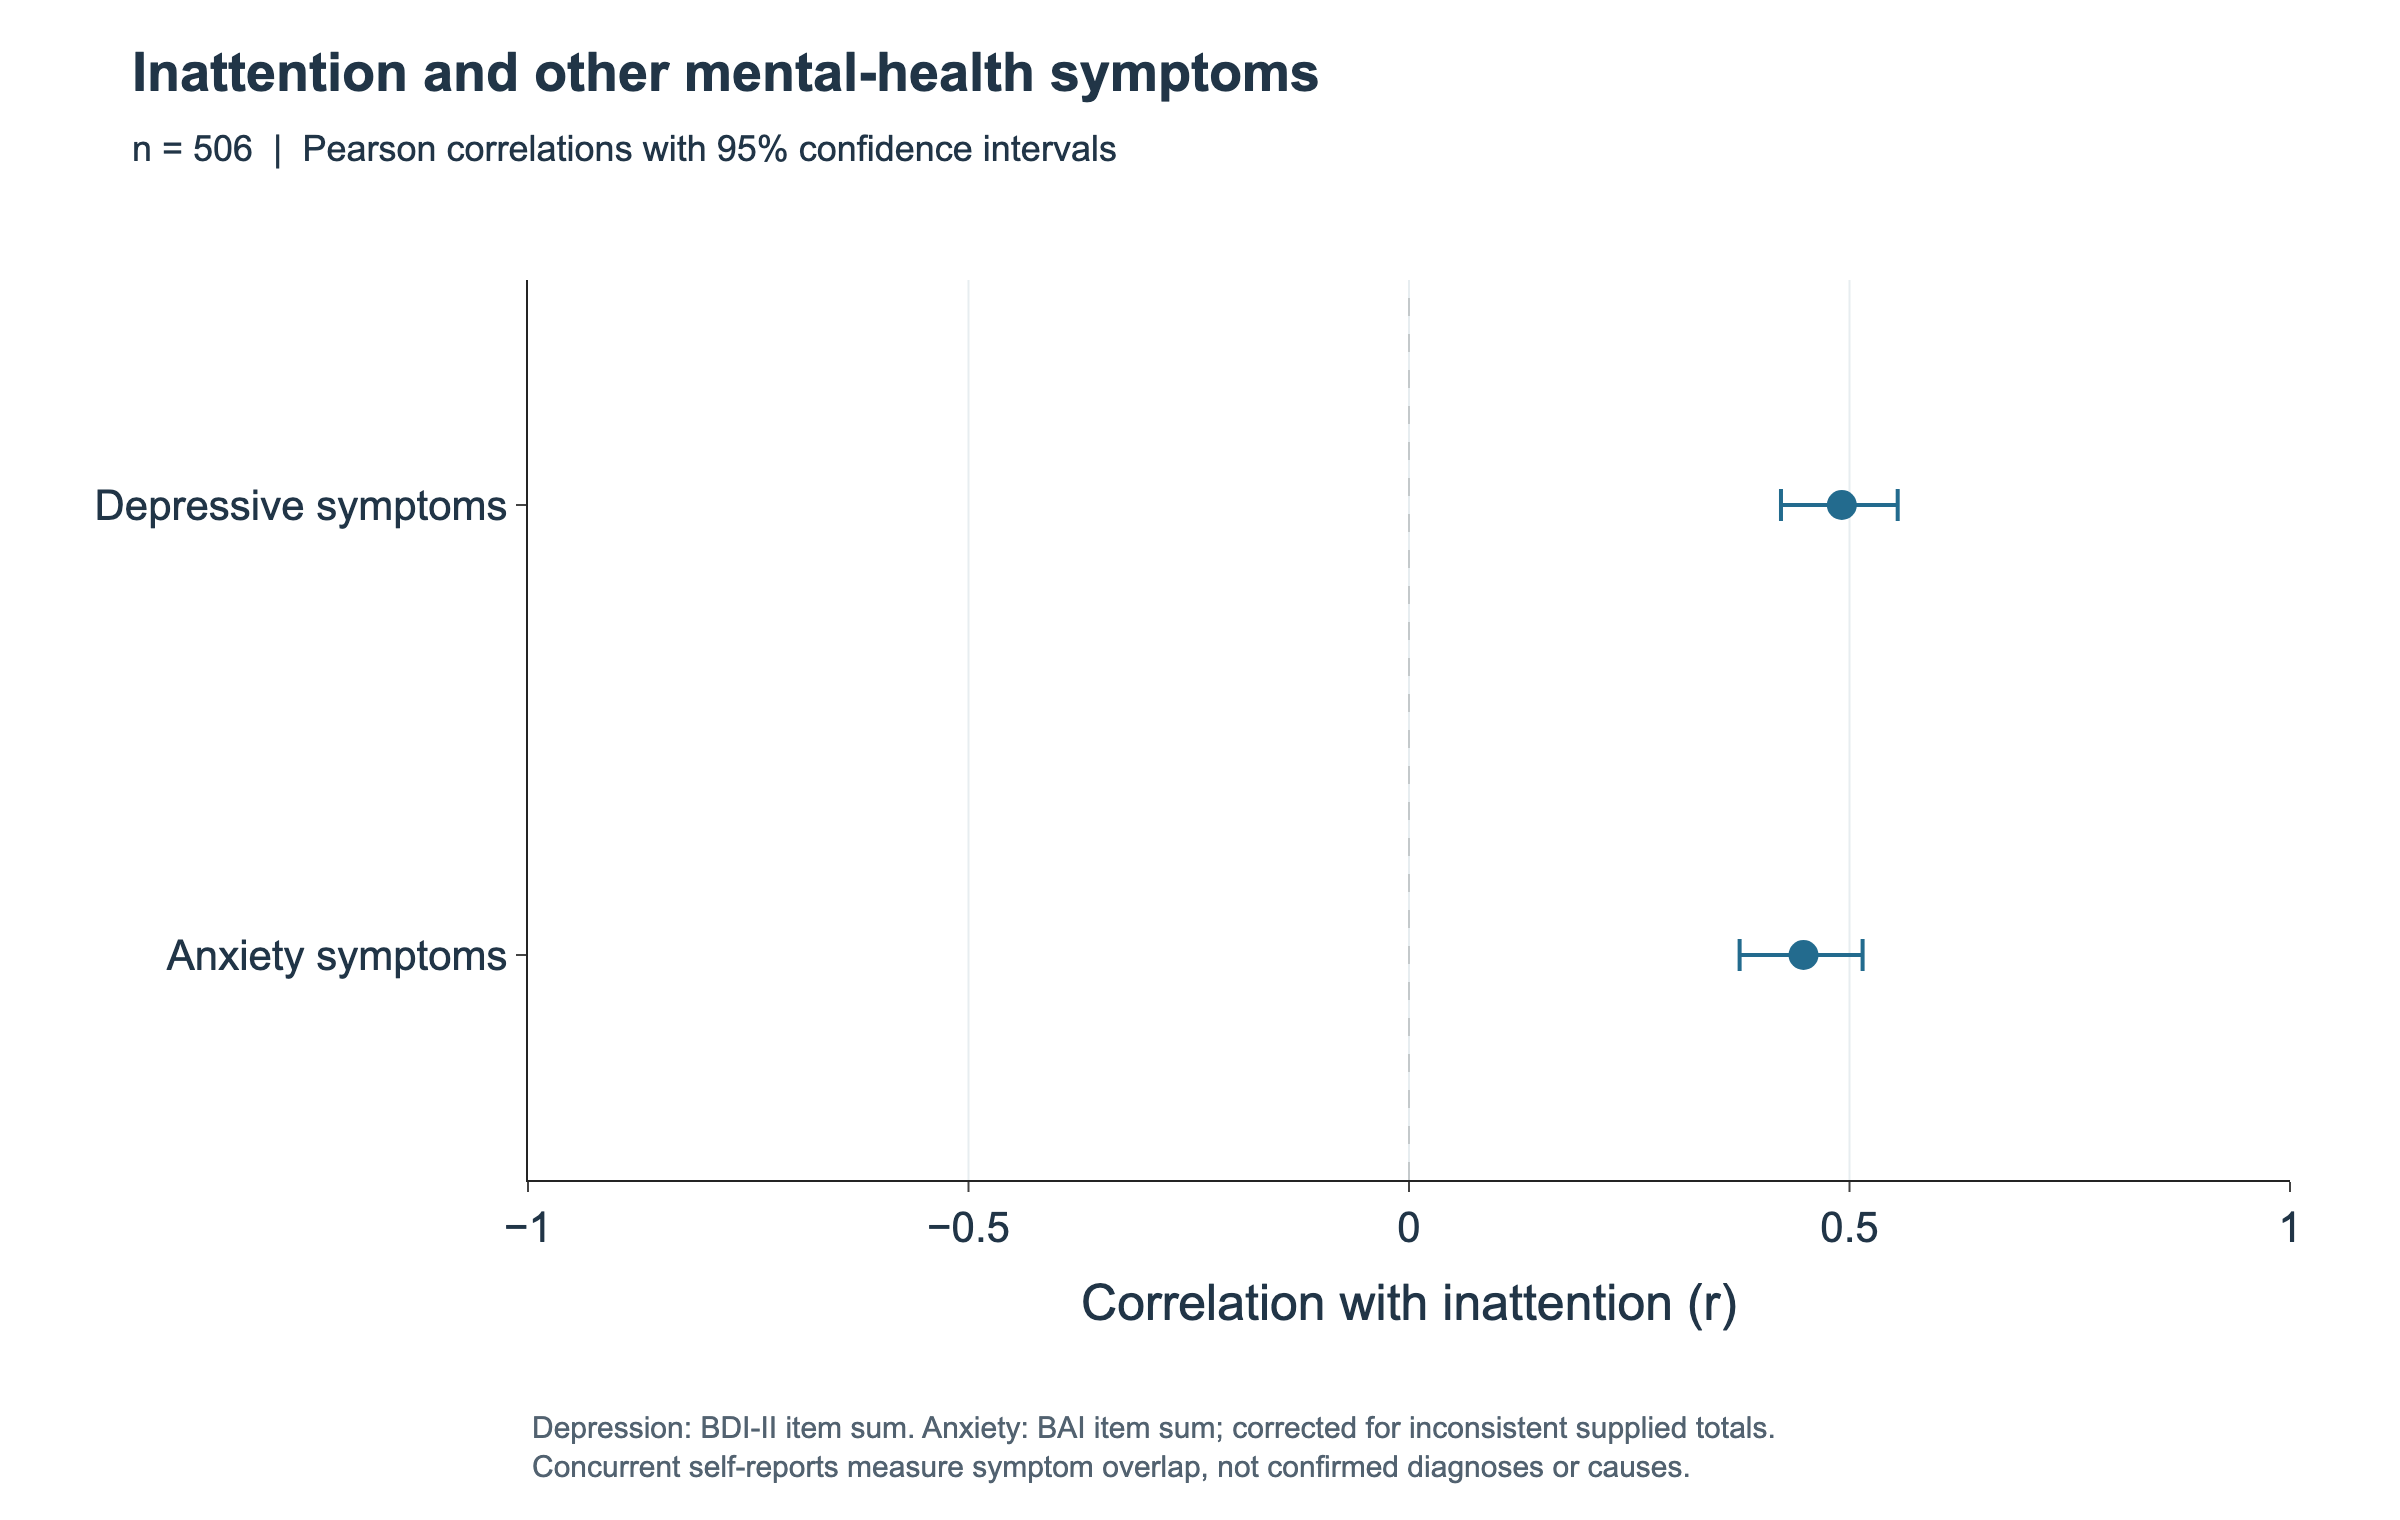

In [18]:
png_path = ROOT / "outputs/inattention_and_mental_health_symptoms.png"
if png_path.exists():
    display(Image(filename=str(png_path), width=1000))
else:
    display(figures["inattention_and_mental_health_symptoms"])

## 5. Audit, limitations, and presentation recommendations

The summary below reports the calculated results and ranks three graphs by their relevance to the support-needs question. The best graph for “Why this problem matters” is identified explicitly. Generalizing to Kazakhstan and testing support effectiveness require different evidence.

In [19]:
def write_reports(d, result, metadata, checks, root):
    root = Path(root)
    assoc = result['associations'].set_index('test_id')
    a = assoc.loc['inattention__adjustment']
    b = assoc.loc['inattention__course_mark']
    t = assoc.loc['adhd_total__course_mark']
    change = assoc.loc['inattention__adjustment_change']
    g = result['group_test']
    coef = result['coefficients'].set_index(['model','term'])
    ci = coef.loc[('marks_adjusted_sd','inattention')]
    ch = coef.loc[('marks_adjusted_sd','hyperactivity')]
    ui = coef.loc[('marks_joint_sd','inattention')]
    uh = coef.loc[('marks_joint_sd','hyperactivity')]
    def describe_r(r):
        return (f'n = {int(r.n)}; Pearson r = {r.pearson_r:.3f}, 95% CI [{r.r_ci_low:.3f}, {r.r_ci_high:.3f}]; '
                f'p = {pstr(r.p)}, Holm-adjusted p = {pstr(r.p_holm)}')
    summary = f'''# ADHD and academic outcomes: presentation findings

{NO_SUPPORT}

The supplied main sheet contains **506 students and 110 columns**. General psychiatric medication and therapy/counselling questions do not identify academic accommodations, institutional providers, ADHD-specific care, coaching, tutoring, or mentoring. No support proxy or support comparison was created.

The available university outcome is **`psy1004_grade`**, presented conservatively as a PSY1004 course mark (%), **not GPA**. The published paper describes a different, semester-wide GPA outcome; it must not be substituted for this workbook column. These are new analyses of the supplied workbook, not a replication of every published result.

### Best Graphs for the Presentation

Ranked by usefulness for this research question, not p-value alone. These are the three recommended graphs; the remaining graphs are supporting analyses.

**1. [Inattention and academic adjustment](outputs/inattention_vs_academic_adjustment.html) — best for “Why this problem matters.”**

- Shows: students with more inattentive symptoms tend to report poorer academic adjustment.
- Exact variables: `inattention` = sum of `asrs1_item_1`–`asrs1_item_4` and `asrs1_item_7`–`asrs1_item_11`; `adjustment` = sum of `aas1_item_1`–`aas1_item_9`, requiring all nine responses. This equals `aas1_total` for complete responses. Higher AAS scores mean better adjustment.
- Result: {describe_r(a)}. Each 5-point increase in inattention corresponds to {5*a.slope:.2f} adjustment points (95% HC3 CI [{5*a.slope_ci_low:.2f}, {5*a.slope_ci_high:.2f}]). Shared variance is {100*a.R_squared:.1f}%.
- Relevance / legitimate claim: identifies a modest academic-adjustment difficulty associated with inattention, a possible target for support research.
- Cannot claim: that inattention caused the difficulty, that ADHD was clinically diagnosed, that support would improve outcomes, or that this establishes a support gap in Kazakhstan. Both measures are concurrent self-reports.

Suggested slide sentence: **“In this South African first-year sample, greater inattention was associated with poorer academic adjustment (r = {a.pearson_r:.2f}, n = {int(a.n)}).”**

**2. [Inattention and course marks](outputs/inattention_vs_academic_performance.html).**

- Shows: a small downward association with an academic mark, alongside substantial individual variation.
- Exact variables: the same nine-item `inattention` sum and `psy1004_grade` (analysis alias `course_mark`).
- Result: {describe_r(b)}. A 5-point higher inattention score corresponds to {5*b.slope:.2f} percentage points (95% HC3 CI [{5*b.slope_ci_low:.2f}, {5*b.slope_ci_high:.2f}]); shared variance = {100*b.R_squared:.1f}%. The association does not pass the primary-family Holm threshold.
- Relevance / legitimate claim: a small unadjusted academic-performance association supports investigating needs, while keeping its size visible. The coefficient is weaker after age and prior attainment are included (graph 3).
- Cannot claim: a strong or causal grade penalty, an independent association established after covariate adjustment, a GPA effect, or a benefit of accommodations.

**3. [Symptom dimensions and prior attainment](outputs/symptom_dimensions_vs_academic_performance.html).**

- Shows: the two symptom dimensions in the same regression, before and after adding age and earlier academic attainment.
- Exact variables: `psy1004_grade`; `inattention` as above; `hyperactivity` = sum of `asrs1_item_5`, `asrs1_item_6`, and `asrs1_item_12`–`asrs1_item_18`; covariates `age`, `matric_mark`, `nbt_alql_ave`. Symptom predictors are standardized; outcome remains percentage points.
- Result: n = 506. Joint model: inattention B = {ui.coefficient:.2f} (95% CI [{ui.ci_low:.2f}, {ui.ci_high:.2f}], p = {pstr(ui.p)}); hyperactivity B = {uh.coefficient:.2f} ([{uh.ci_low:.2f}, {uh.ci_high:.2f}], p = {pstr(uh.p)}), R² = {ui.R_squared:.3f}. With covariates: inattention B = {ci.coefficient:.2f} ([{ci.ci_low:.2f}, {ci.ci_high:.2f}], p = {pstr(ci.p)}); hyperactivity B = {ch.coefficient:.2f} ([{ch.ci_low:.2f}, {ch.ci_high:.2f}], p = {pstr(ch.p)}), R² = {ci.R_squared:.3f}. All intervals are HC3; covariate-model p-values are exploratory and nominal.
- Relevance / legitimate claim: inattention is the negatively associated dimension in the simple joint model, but prior attainment changes the interpretation. The overall ADHD total can conceal different conditional associations.
- Cannot claim: hyperactivity improves grades, a causal executive-function mechanism, or an independent inattention effect established by the covariate model. Conditional positive coefficients can reflect correlated predictors/suppression. The larger R² is for the entire model, not ADHD alone.

### Other planned results, including null findings

- Overall ADHD severity versus marks: {describe_r(t)}. There is no clear linear association; this is not proof of no relationship.
- Screening comparison: ASRS six-item sum ≥14 defines **screen positive**, not diagnosed ADHD. Screen negative is not confirmed absence of ADHD.

{mdtable(result['groups'][['group','n','mean','median','sd','mean_ci_low','mean_ci_high']])}

Positive-minus-negative mean difference = {g['mean_difference_positive_minus_negative']:.2f} percentage points, 95% CI [{g['difference_ci_low']:.2f}, {g['difference_ci_high']:.2f}]; Welch t({g['welch_df']:.1f}) = {g['welch_t']:.2f}, p = {pstr(g['p'])}, Holm p = {pstr(g['p_holm'])}; Cohen’s d = {g['cohens_d']:.3f}, Hedges’ g = {g['hedges_g']:.3f}, bootstrap 95% CI [{g['g_bootstrap_ci_low']:.3f}, {g['g_bootstrap_ci_high']:.3f}]. Mann–Whitney sensitivity p = {pstr(g['mann_whitney_p'])}. This small contrast does not pass the primary-family Holm threshold. No diagnostic prevalence estimate is inferred.

- Imported adjustment-change index: {describe_r(change)}. This is exploratory: only 176/506 have a value, wave-2/3 scores and the derivation code are absent, and model units are not raw AAS-point changes. Students with a change value have higher average course marks (62.72% versus 59.35%), so subset selection matters. The paper’s reported adjustment sample (180) differs from the workbook’s available 176.
- Targeted symptom overlap: inattention–depression r = {assoc.loc['inattention__depression','pearson_r']:.3f}; inattention–anxiety r = {assoc.loc['inattention__anxiety','pearson_r']:.3f}, both n = 506 and secondary Holm p < .001. These are symptom correlations, not confirmed comorbid diagnoses. They motivate studying coordinated academic and mental-health support, without establishing intervention effectiveness.
- No GPA, degree-completion, dropout, or confirmed course pass/fail variable is supplied. A mark threshold was not invented. No exploratory demographic fishing was performed.

### Interpretation for Kazakhstan

This sample can motivate a **question about support needs**. It cannot establish the availability of ADHD-specific infrastructure in Kazakhstan or estimate the benefit of support there. Those claims require local institutional evidence and a dataset measuring clearly defined support exposure and academic outcomes.

### Methods and reproducibility

Analyses use one row per student in `Sheet1`. The headerless `Outliers` sheet has ten records with missing course marks and broken references; it is documented but not appended. No new outlier trimming or imputation is used in the primary analyses. Scale sums require complete items. There is no participant identifier to independently validate longitudinal linkage.

Pearson correlations have Fisher-z 95% CIs; Spearman correlations check robustness to ranks. OLS uses HC3 robust standard errors and t-based intervals; scatter bands are confidence intervals for the mean, not individual prediction intervals. Welch’s test estimates the difference in group means without assuming equal variances. Large groups and mild skew support it; Mann–Whitney is a sensitivity test of distributions, not automatically a median test. Cohen’s d uses pooled within-group SD; Hedges’ g corrects small-sample bias; its interval uses 5,000 within-group bootstrap samples (seed {SEED}).

Holm correction is applied to ten primary tests: six symptom–academic correlations, one screening Welch test, two joint-model symptom coefficients, and their standardized contrast. Four secondary correlations form a separate Holm family. CI coverage is pointwise, not simultaneous. Spearman, covariate models, and other sensitivity p-values are nominal and exploratory. Selection into the available cohort and shared self-report measurement remain limitations.

Primary model: `course_mark ~ inattention + hyperactivity`. Covariate sensitivity: add `age + matric_mark + nbt_alql`. NBT academic/quantitative-literacy average is used consistently, avoiding interpretation of math zeroes for students who did not take that test. Both symptom dimensions have the same 0–36 raw range; the comparison graph scales each by its sample SD. Direct coefficient contrast and VIFs are saved in tables. The two-sided standardized contrast is {result['contrast']['difference_per_SD']:.2f} percentage points, 95% CI [{result['contrast']['ci_low']:.2f}, {result['contrast']['ci_high']:.2f}], p = {pstr(result['contrast']['p'])}, Holm p = {pstr(result['contrast']['p_holm'])}; this is a signed conditional contrast, not a causal ranking.

### Sources

- Dataset: Rousseau, Mohamad, Dowlut, Gering & Thomas, [UCT/Zivahub, CC BY 4.0]({DATA_URL}); supplied locally through the [Kaggle mirror](https://www.kaggle.com/datasets/imtkaggleteam/adhd-mental-health).
- Variable interpretation: Mohamad et al. (2025), [original study methods and limitations]({STUDY_URL}). Used for instrument meanings, item groupings, and study context; published results were not substituted for calculations.
- Screening rule: Harvard/NCS, [ASRS v1.1 six-question scoring update, February 2024]({SCREEN_URL}). Six-item sum 0–24, positive at ≥14; screening is not diagnosis. ASRS attribution: © New York University and the President and Fellows of Harvard College. Item wording is not reproduced.

See `DATA_AUDIT.md`, the executed notebook, and `tables/` for every estimate, missingness count, data-quality decision, and sensitivity result.
'''
    (root/'PRESENTATION_SUMMARY.md').write_text(summary)
    audit = f'''# Data audit and variable decisions

{NO_SUPPORT}

## What was inspected

Archive: {metadata['archive_members']}. Main sheet: {metadata['main_shape']}; headerless Outliers sheet: {metadata['outliers_shape_headerless']}. No dictionary file, cell comments, named ranges, or hidden documentation sheets were supplied. All 110 column names, types, missingness counts and descriptive statistics are printed in `analysis_log.txt` and the notebook; complete categorical value counts are in `tables/categorical_value_counts.json`. The online study was used to resolve instrument names, not to assume unseen columns.

## Important quality issues

{mdtable(checks)}

1. `asrs1_total.x` equals the 18-item ASRS sum in all 506 rows. `asrs1_total.y` equals that sum in only {metadata['asrs_y_item_sum_matches']} rows and equals the anxiety item sum in {metadata['asrs_y_anxiety_item_sum_matches']} rows. The latter is excluded; its exact provenance is unresolved.
2. Eighteen `aas1_total` values have at least one missing AAS item. Main adjustment analyses require all nine items (n = 488); retaining the supplied totals is explicitly a sensitivity analysis. The arithmetic minimum of nine 1–5 items is 9, not 1.
3. Sixty-one `bai1_total` values disagree with the sum of the 21 complete BAI items. Anxiety is reconstructed from the items; supplied totals are retained only for sensitivity.
4. `aas_change` has 176 observations and 330 blanks. No later-wave item/total columns or derivation script exist in this workbook. Interpret as an imported, source-described model-derived index, not raw change, and do not reproduce the paper's n = 180 by imputation.
5. `psy1004_grade` spans 28–88 and identifies a course. It is not renamed GPA. Percentage-scale interpretation is consistent with the values and academic-mark context; a workbook-specific dictionary is absent.
6. The ten headerless Outliers rows all lack course marks and contain broken spreadsheet references. They are not a second sample or grounds to delete more main-sheet rows. No exact duplicate main rows were found.
7. Literal `not applicable`, `none`, `no`, and similar responses are preserved as categories. Only actual blanks are missing in the initial profile. In particular, `not applicable` is not recoded as untreated/no support.
8. The original study reports prior imputation; the workbook has no item-level imputation flags. Complete observed workbook items are analyzed as supplied; uncertainty from prior processing cannot be recovered.

## Variable map

| Construct | Exact source / rule | Decision |
| --- | --- | --- |
| ADHD symptoms | `asrs1_item_1`–`asrs1_item_18`; validated `asrs1_total.x` | Continuous 0–72, not diagnosis |
| Inattention | items 1–4 and 7–11 of ASRS | Sum 0–36 |
| Hyperactivity/impulsivity | items 5–6 and 12–18 of ASRS | Sum 0–36 |
| ADHD screen | first six ASRS items summed, ≥14 positive | Secondary group comparison; no clinical label |
| Diagnosis | `have_you_ever_been_diagnosed_with_a_mental_illness` and free-text `if_you_have_been_diagnosed_formally_or_informally_please_list_the_diagnosis_diagnoses` | Broad diagnosis question plus mixed formal/informal narratives cannot define confirmed ADHD vs confirmed absence |
| Course performance | `psy1004_grade` | Course mark %, not semester GPA |
| Academic adjustment | nine `aas1_item_*` responses; complete-case total | 9–45, higher = better; baseline, not final adjustment |
| Adjustment change | `aas_change` | Exploratory imported model index, unavailable derivation |
| Earlier attainment | `matric_mark`, `nbt_alql_ave` | Covariate sensitivity only; not university outcomes |
| Depression / anxiety | sums of 21 `bdi1_item_*` / `bai1_item_*` | Symptom overlap only, not diagnostic comorbidity |
| Medication | ever/current prescribed psychiatric medication questions | No indication, drug, dose, ADHD specificity or institutional provider |
| Counselling | ever/current therapy or counselling for mental illness/symptoms | General mental-health care, not academic support |
| Accommodations, disability services, coaching, tutoring, advising, mentoring | No defensible fields | No comparison |
| Help-seeking / engagement | No structured service-use or engagement measure | Do not convert narratives or AAS into exposure variables |

The complete keyword search is in `tables/variable_search.csv`. Example response labels for medication and counselling are `yes`, `no`, and `not applicable`; diagnosis labels include formal diagnosis, not formally diagnosed, and no. Provider and service purpose remain unknown.

Dataset: {DATA_URL}. Methods: {STUDY_URL}. Screening: {SCREEN_URL}.
'''
    (root/'DATA_AUDIT.md').write_text(audit)
    readme = '''# ADHD academic analysis

Start with **PRESENTATION_SUMMARY.md** for the ranked three graphs and slide wording.

See [METHODS_FAQ.md](METHODS_FAQ.md) for why Welch's test was used and what the Holm adjustment means.

- `adhd_academic_analysis.ipynb`: executed notebook with complete analysis code, tables and graphs.
- `analysis.py`: reproducible pipeline.
- `outputs/`: eight interactive, standalone Plotly HTML graphs and high-resolution PNGs when exported.
- `tables/`: full inspection, statistics, regression results, diagnostics and sensitivity checks.
- `DATA_AUDIT.md`: variable interpretation and cleaning decisions.
- `data/ADHD.xlsx`: exact supplied workbook; `analysis_variables.csv`: reproducible derived numeric variables.
- `analysis_log.txt`: printed inspection and all main numerical results.

## Rerun

```sh
cd ~/Desktop/adhd_academic_analysis
.venv/bin/python analysis.py
```

On another machine, create a Python environment and install `requirements.txt`, then run `python analysis.py`. HTML export works without a browser. PNG export requires Kaleido and its Chrome component; this machine has a project-local browser in `.browser`. Use `--skip-png` if unavailable. No source-data network access is needed.

The main findings concern associations with symptoms. The data do not measure institutional academic support, support effectiveness, or conditions in Kazakhstan. Do not describe screen-positive groups as clinically diagnosed, and do not relabel the course mark as GPA.

## Dataset attribution

Rousseau, Kim; Mohamad, Nawal; Dowlut, Fatimah; Gering, Milton; Thomas, Kevin. *ADHD and Common Mental Disorders: Effect on Academic Success in SA First-Years*. [UCT/Zivahub dataset](https://doi.org/10.25375/uct.24906924), licensed [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/), obtained through the [Kaggle mirror](https://www.kaggle.com/datasets/imtkaggleteam/adhd-mental-health). The supplied workbook is unchanged; derived variables, analyses and visualizations are documented in `DATA_AUDIT.md` and the notebook. The dataset license does not automatically license the analysis code.
'''
    (root/'README.md').write_text(readme)
    return summary

In [20]:
summary = write_reports(d, result, metadata, checks, ROOT)
display(Markdown((ROOT / "DATA_AUDIT.md").read_text()))

# Data audit and variable decisions

This dataset does not contain a sufficiently clear variable for institutional academic support, so a support-vs-no-support comparison would not be valid.

## What was inspected

Archive: ['ADHD.xlsx']. Main sheet: [506, 110]; headerless Outliers sheet: [10, 111]. No dictionary file, cell comments, named ranges, or hidden documentation sheets were supplied. All 110 column names, types, missingness counts and descriptive statistics are printed in `analysis_log.txt` and the notebook; complete categorical value counts are in `tables/categorical_value_counts.json`. The online study was used to resolve instrument names, not to assume unseen columns.

## Important quality issues

| scale | item_complete_n | item_incomplete_n | stored_total_mismatches_among_complete |
| --- | --- | --- | --- |
| asrs1 | 506 | 0 | 0 |
| aas1 | 488 | 18 | 0 |
| bdi1 | 506 | 0 | 0 |
| bai1 | 506 | 0 | 61 |

1. `asrs1_total.x` equals the 18-item ASRS sum in all 506 rows. `asrs1_total.y` equals that sum in only 7 rows and equals the anxiety item sum in 503 rows. The latter is excluded; its exact provenance is unresolved.
2. Eighteen `aas1_total` values have at least one missing AAS item. Main adjustment analyses require all nine items (n = 488); retaining the supplied totals is explicitly a sensitivity analysis. The arithmetic minimum of nine 1–5 items is 9, not 1.
3. Sixty-one `bai1_total` values disagree with the sum of the 21 complete BAI items. Anxiety is reconstructed from the items; supplied totals are retained only for sensitivity.
4. `aas_change` has 176 observations and 330 blanks. No later-wave item/total columns or derivation script exist in this workbook. Interpret as an imported, source-described model-derived index, not raw change, and do not reproduce the paper's n = 180 by imputation.
5. `psy1004_grade` spans 28–88 and identifies a course. It is not renamed GPA. Percentage-scale interpretation is consistent with the values and academic-mark context; a workbook-specific dictionary is absent.
6. The ten headerless Outliers rows all lack course marks and contain broken spreadsheet references. They are not a second sample or grounds to delete more main-sheet rows. No exact duplicate main rows were found.
7. Literal `not applicable`, `none`, `no`, and similar responses are preserved as categories. Only actual blanks are missing in the initial profile. In particular, `not applicable` is not recoded as untreated/no support.
8. The original study reports prior imputation; the workbook has no item-level imputation flags. Complete observed workbook items are analyzed as supplied; uncertainty from prior processing cannot be recovered.

## Variable map

| Construct | Exact source / rule | Decision |
| --- | --- | --- |
| ADHD symptoms | `asrs1_item_1`–`asrs1_item_18`; validated `asrs1_total.x` | Continuous 0–72, not diagnosis |
| Inattention | items 1–4 and 7–11 of ASRS | Sum 0–36 |
| Hyperactivity/impulsivity | items 5–6 and 12–18 of ASRS | Sum 0–36 |
| ADHD screen | first six ASRS items summed, ≥14 positive | Secondary group comparison; no clinical label |
| Diagnosis | `have_you_ever_been_diagnosed_with_a_mental_illness` and free-text `if_you_have_been_diagnosed_formally_or_informally_please_list_the_diagnosis_diagnoses` | Broad diagnosis question plus mixed formal/informal narratives cannot define confirmed ADHD vs confirmed absence |
| Course performance | `psy1004_grade` | Course mark %, not semester GPA |
| Academic adjustment | nine `aas1_item_*` responses; complete-case total | 9–45, higher = better; baseline, not final adjustment |
| Adjustment change | `aas_change` | Exploratory imported model index, unavailable derivation |
| Earlier attainment | `matric_mark`, `nbt_alql_ave` | Covariate sensitivity only; not university outcomes |
| Depression / anxiety | sums of 21 `bdi1_item_*` / `bai1_item_*` | Symptom overlap only, not diagnostic comorbidity |
| Medication | ever/current prescribed psychiatric medication questions | No indication, drug, dose, ADHD specificity or institutional provider |
| Counselling | ever/current therapy or counselling for mental illness/symptoms | General mental-health care, not academic support |
| Accommodations, disability services, coaching, tutoring, advising, mentoring | No defensible fields | No comparison |
| Help-seeking / engagement | No structured service-use or engagement measure | Do not convert narratives or AAS into exposure variables |

The complete keyword search is in `tables/variable_search.csv`. Example response labels for medication and counselling are `yes`, `no`, and `not applicable`; diagnosis labels include formal diagnosis, not formally diagnosed, and no. Provider and service purpose remain unknown.

Dataset: https://doi.org/10.25375/uct.24906924. Methods: https://doi.org/10.1177/10870547241310659. Screening: https://www.hcp.med.harvard.edu/ncs/ftpdir/adhd/ASRS_v1.1_screener%286Q%29_scoring_update.pdf.


In [21]:
display(Markdown(summary))

# ADHD and academic outcomes: presentation findings

This dataset does not contain a sufficiently clear variable for institutional academic support, so a support-vs-no-support comparison would not be valid.

The supplied main sheet contains **506 students and 110 columns**. General psychiatric medication and therapy/counselling questions do not identify academic accommodations, institutional providers, ADHD-specific care, coaching, tutoring, or mentoring. No support proxy or support comparison was created.

The available university outcome is **`psy1004_grade`**, presented conservatively as a PSY1004 course mark (%), **not GPA**. The published paper describes a different, semester-wide GPA outcome; it must not be substituted for this workbook column. These are new analyses of the supplied workbook, not a replication of every published result.

### Best Graphs for the Presentation

Ranked by usefulness for this research question, not p-value alone. These are the three recommended graphs; the remaining graphs are supporting analyses.

**1. [Inattention and academic adjustment](outputs/inattention_vs_academic_adjustment.html) — best for “Why this problem matters.”**

- Shows: students with more inattentive symptoms tend to report poorer academic adjustment.
- Exact variables: `inattention` = sum of `asrs1_item_1`–`asrs1_item_4` and `asrs1_item_7`–`asrs1_item_11`; `adjustment` = sum of `aas1_item_1`–`aas1_item_9`, requiring all nine responses. This equals `aas1_total` for complete responses. Higher AAS scores mean better adjustment.
- Result: n = 488; Pearson r = -0.205, 95% CI [-0.288, -0.118]; p = 5.12e-06, Holm-adjusted p = 5.12e-05. Each 5-point increase in inattention corresponds to -0.74 adjustment points (95% HC3 CI [-1.07, -0.40]). Shared variance is 4.2%.
- Relevance / legitimate claim: identifies a modest academic-adjustment difficulty associated with inattention, a possible target for support research.
- Cannot claim: that inattention caused the difficulty, that ADHD was clinically diagnosed, that support would improve outcomes, or that this establishes a support gap in Kazakhstan. Both measures are concurrent self-reports.

Suggested slide sentence: **“In this South African first-year sample, greater inattention was associated with poorer academic adjustment (r = -0.20, n = 488).”**

**2. [Inattention and course marks](outputs/inattention_vs_academic_performance.html).**

- Shows: a small downward association with an academic mark, alongside substantial individual variation.
- Exact variables: the same nine-item `inattention` sum and `psy1004_grade` (analysis alias `course_mark`).
- Result: n = 506; Pearson r = -0.107, 95% CI [-0.193, -0.020]; p = 0.016, Holm-adjusted p = 0.080. A 5-point higher inattention score corresponds to -0.90 percentage points (95% HC3 CI [-1.65, -0.14]); shared variance = 1.1%. The association does not pass the primary-family Holm threshold.
- Relevance / legitimate claim: a small unadjusted academic-performance association supports investigating needs, while keeping its size visible. The coefficient is weaker after age and prior attainment are included (graph 3).
- Cannot claim: a strong or causal grade penalty, an independent association established after covariate adjustment, a GPA effect, or a benefit of accommodations.

**3. [Symptom dimensions and prior attainment](outputs/symptom_dimensions_vs_academic_performance.html).**

- Shows: the two symptom dimensions in the same regression, before and after adding age and earlier academic attainment.
- Exact variables: `psy1004_grade`; `inattention` as above; `hyperactivity` = sum of `asrs1_item_5`, `asrs1_item_6`, and `asrs1_item_12`–`asrs1_item_18`; covariates `age`, `matric_mark`, `nbt_alql_ave`. Symptom predictors are standardized; outcome remains percentage points.
- Result: n = 506. Joint model: inattention B = -2.16 (95% CI [-3.42, -0.91], p = 7.60e-04); hyperactivity B = 1.68 ([0.53, 2.84], p = 0.004), R² = 0.027. With covariates: inattention B = -0.93 ([-2.02, 0.16], p = 0.093); hyperactivity B = 0.42 ([-0.61, 1.45], p = 0.422), R² = 0.294. All intervals are HC3; covariate-model p-values are exploratory and nominal.
- Relevance / legitimate claim: inattention is the negatively associated dimension in the simple joint model, but prior attainment changes the interpretation. The overall ADHD total can conceal different conditional associations.
- Cannot claim: hyperactivity improves grades, a causal executive-function mechanism, or an independent inattention effect established by the covariate model. Conditional positive coefficients can reflect correlated predictors/suppression. The larger R² is for the entire model, not ADHD alone.

### Other planned results, including null findings

- Overall ADHD severity versus marks: n = 506; Pearson r = -0.041, 95% CI [-0.127, 0.047]; p = 0.360, Holm-adjusted p = 1.000. There is no clear linear association; this is not proof of no relationship.
- Screening comparison: ASRS six-item sum ≥14 defines **screen positive**, not diagnosed ADHD. Screen negative is not confirmed absence of ADHD.

| group | n | mean | median | sd | mean_ci_low | mean_ci_high |
| --- | --- | --- | --- | --- | --- | --- |
| Screen negative | 255 | 61.580 | 62.000 | 11.619 | 60.147 | 63.013 |
| Screen positive | 251 | 59.442 | 60.000 | 10.674 | 58.115 | 60.769 |

Positive-minus-negative mean difference = -2.14 percentage points, 95% CI [-4.09, -0.19]; Welch t(501.6) = -2.16, p = 0.032, Holm p = 0.126; Cohen’s d = -0.192, Hedges’ g = -0.191, bootstrap 95% CI [-0.367, -0.014]. Mann–Whitney sensitivity p = 0.042. This small contrast does not pass the primary-family Holm threshold. No diagnostic prevalence estimate is inferred.

- Imported adjustment-change index: n = 176; Pearson r = -0.328, 95% CI [-0.454, -0.189]; p = 9.02e-06, Holm-adjusted p = 1.80e-05. This is exploratory: only 176/506 have a value, wave-2/3 scores and the derivation code are absent, and model units are not raw AAS-point changes. Students with a change value have higher average course marks (62.72% versus 59.35%), so subset selection matters. The paper’s reported adjustment sample (180) differs from the workbook’s available 176.
- Targeted symptom overlap: inattention–depression r = 0.491; inattention–anxiety r = 0.448, both n = 506 and secondary Holm p < .001. These are symptom correlations, not confirmed comorbid diagnoses. They motivate studying coordinated academic and mental-health support, without establishing intervention effectiveness.
- No GPA, degree-completion, dropout, or confirmed course pass/fail variable is supplied. A mark threshold was not invented. No exploratory demographic fishing was performed.

### Interpretation for Kazakhstan

This sample can motivate a **question about support needs**. It cannot establish the availability of ADHD-specific infrastructure in Kazakhstan or estimate the benefit of support there. Those claims require local institutional evidence and a dataset measuring clearly defined support exposure and academic outcomes.

### Methods and reproducibility

Analyses use one row per student in `Sheet1`. The headerless `Outliers` sheet has ten records with missing course marks and broken references; it is documented but not appended. No new outlier trimming or imputation is used in the primary analyses. Scale sums require complete items. There is no participant identifier to independently validate longitudinal linkage.

Pearson correlations have Fisher-z 95% CIs; Spearman correlations check robustness to ranks. OLS uses HC3 robust standard errors and t-based intervals; scatter bands are confidence intervals for the mean, not individual prediction intervals. Welch’s test estimates the difference in group means without assuming equal variances. Large groups and mild skew support it; Mann–Whitney is a sensitivity test of distributions, not automatically a median test. Cohen’s d uses pooled within-group SD; Hedges’ g corrects small-sample bias; its interval uses 5,000 within-group bootstrap samples (seed 20260916).

Holm correction is applied to ten primary tests: six symptom–academic correlations, one screening Welch test, two joint-model symptom coefficients, and their standardized contrast. Four secondary correlations form a separate Holm family. CI coverage is pointwise, not simultaneous. Spearman, covariate models, and other sensitivity p-values are nominal and exploratory. Selection into the available cohort and shared self-report measurement remain limitations.

Primary model: `course_mark ~ inattention + hyperactivity`. Covariate sensitivity: add `age + matric_mark + nbt_alql`. NBT academic/quantitative-literacy average is used consistently, avoiding interpretation of math zeroes for students who did not take that test. Both symptom dimensions have the same 0–36 raw range; the comparison graph scales each by its sample SD. Direct coefficient contrast and VIFs are saved in tables. The two-sided standardized contrast is -3.85 percentage points, 95% CI [-6.00, -1.69], p = 4.84e-04, Holm p = 0.004; this is a signed conditional contrast, not a causal ranking.

### Sources

- Dataset: Rousseau, Mohamad, Dowlut, Gering & Thomas, [UCT/Zivahub, CC BY 4.0](https://doi.org/10.25375/uct.24906924); supplied locally through the [Kaggle mirror](https://www.kaggle.com/datasets/imtkaggleteam/adhd-mental-health).
- Variable interpretation: Mohamad et al. (2025), [original study methods and limitations](https://doi.org/10.1177/10870547241310659). Used for instrument meanings, item groupings, and study context; published results were not substituted for calculations.
- Screening rule: Harvard/NCS, [ASRS v1.1 six-question scoring update, February 2024](https://www.hcp.med.harvard.edu/ncs/ftpdir/adhd/ASRS_v1.1_screener%286Q%29_scoring_update.pdf). Six-item sum 0–24, positive at ≥14; screening is not diagnosis. ASRS attribution: © New York University and the President and Fellows of Harvard College. Item wording is not reproduced.

See `DATA_AUDIT.md`, the executed notebook, and `tables/` for every estimate, missingness count, data-quality decision, and sensitivity result.
